In [1]:
import os
import random
import json
import hashlib
from datetime import datetime, timezone
from pathlib import Path
from typing import Dict, Tuple, List, Optional
import warnings
from itertools import combinations as _combinations
from collections import Counter

import re
import textwrap
import shap
import gseapy as gp
from gprofiler import GProfiler

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from xgboost import XGBRegressor  

from IPython.display import display

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.metrics import r2_score

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

SEED = 19537
EXTRA_SEEDS = [19537, 1584678, 17052356]  
SEEDS_TO_RUN = EXTRA_SEEDS

def seed_suffix(seed: int) -> str:
    return f"_seed{seed}"

def set_seeds(seed: int) -> None:
    global SEED, RNG, XGB_PARAMS
    SEED = int(seed)
    random.seed(SEED)
    np.random.seed(SEED)
    RNG = np.random.default_rng(SEED)
    XGB_PARAMS["random_state"] = SEED


os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

warnings.filterwarnings(
    "ignore",
    message=".*Falling back to prediction using DMatrix due to mismatched devices.*",
    category=UserWarning,
)

In [2]:
# Paths and configuration

NOTEBOOK_SUBDIR = "notebook 3b"

ARTIFACTS = Path("artifacts")
IN_CLEAN = ARTIFACTS / "cleaned" / "notebook 2"
IN_T2 = ARTIFACTS / "aligned" / "notebook 1" / "track2_nonintersection"

OUT_REPORTS = ARTIFACTS / "reports" / NOTEBOOK_SUBDIR
OUT_META = ARTIFACTS / "metadata" / NOTEBOOK_SUBDIR

for d in [OUT_REPORTS, OUT_META]:
    d.mkdir(parents=True, exist_ok=True)

RNG = np.random.default_rng(SEED)

# Benchmark settings 
PRIMARY_TARGET = "auc"
N_DRUGS_TOP_BY_COVERAGE = 100      
MIN_MEASURED_CELLS_PER_DRUG = 120   # skip drugs that become too small after arm filtering
N_SPLITS_DESIRED = 10

# Preprocessing (leakage-safe: everything fit on train fold cell lines only)
USE_PCA = True
PCA_COMPONENTS = 200

# Models
RIDGE_ALPHA = 1.0

# Elastic Net (strong linear baseline with correlated features)
USE_ELASTICNET = True
EN_ALPHA = 0.05
EN_L1_RATIO = 0.2

# Forests (tree ensembles)
USE_EXTRATREES = True
ET_N_ESTIMATORS = 400
ET_MAX_DEPTH = None
ET_MIN_SAMPLES_LEAF = 2

USE_RANDOMFOREST = True  
RF_N_ESTIMATORS = 400
RF_MAX_DEPTH = None
RF_MIN_SAMPLES_LEAF = 2

# XGB
USE_XGB = True

USE_GPU_FOR_XGB = True     # set False to force CPU
XGB_DEVICE = "cuda"        # or "cuda:0"

XGB_PARAMS = dict(
    n_estimators=250,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,

    random_state=SEED,

    tree_method="hist",
    device=(XGB_DEVICE if USE_GPU_FOR_XGB else "cpu"),

    n_jobs=-1,
)

# Progress logging (stdout)
PRINT_EVERY_N_DRUGS = 5      # prints one progress line every N drugs per arm
PRINT_PER_FOLD = False       # True prints per-fold sizes (can be noisy)
PRINT_SKIPS = True           # True prints first few skip reasons per arm
MAX_SKIP_PRINTS = 5     
RESUME_FROM_CHECKPOINT = True
CHECKPOINT_EVERY_N_DRUGS = 5  # save state every N processed drugs per arm
def set_paths_for_seed(seed: int) -> dict:
    suf = seed_suffix(seed)
    paths = {
        "checkpoint_rows": OUT_REPORTS / f"prot_backbone_bench_perdrug__checkpoint_auc{suf}.csv",
        "checkpoint_state": OUT_META / f"prot_backbone_bench_state_auc{suf}.json",
        "detail": OUT_REPORTS / f"prot_backbone_bench_perdrug_auc{suf}.csv",
        "perdrug_agg": OUT_REPORTS / f"prot_backbone_bench_perdrug_aggregated_auc{suf}.csv",
        "metrics": OUT_REPORTS / f"prot_backbone_bench_metrics_auc{suf}.csv",
    }
    return paths

In [3]:
# Helpers

def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()

def fingerprint(path: Path) -> dict:
    st = path.stat()
    return {
        "path": str(path.resolve()),
        "size_bytes": int(st.st_size),
        "mtime_utc": datetime.fromtimestamp(st.st_mtime, tz=timezone.utc).isoformat(),
        "sha256": sha256_file(path),
    }

def write_json(obj: dict, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)

def read_json_if_exists(path: Path) -> Optional[dict]:
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

BENCH_COLUMNS = [
    "seed",
    "arm", "compound_id", "fold", "model", "feature_set",
    "n_train", "n_test", "spearman", "r2",
]

def make_run_signature(selected_drugs: List[str], feature_combos: Dict[str, Tuple[str, ...]]) -> str:
    payload = {
        "PRIMARY_TARGET": PRIMARY_TARGET,
        "N_DRUGS_TOP_BY_COVERAGE": N_DRUGS_TOP_BY_COVERAGE,
        "MIN_MEASURED_CELLS_PER_DRUG": MIN_MEASURED_CELLS_PER_DRUG,
        "N_SPLITS_DESIRED": N_SPLITS_DESIRED,
        "USE_PCA": USE_PCA,
        "PCA_COMPONENTS": PCA_COMPONENTS,
        "RIDGE_ALPHA": RIDGE_ALPHA,
        "USE_ELASTICNET": USE_ELASTICNET,
        "EN_ALPHA": EN_ALPHA,
        "EN_L1_RATIO": EN_L1_RATIO,
        "USE_EXTRATREES": USE_EXTRATREES,
        "ET_N_ESTIMATORS": ET_N_ESTIMATORS,
        "ET_MAX_DEPTH": ET_MAX_DEPTH,
        "ET_MIN_SAMPLES_LEAF": ET_MIN_SAMPLES_LEAF,
        "USE_RANDOMFOREST": USE_RANDOMFOREST,
        "RF_N_ESTIMATORS": RF_N_ESTIMATORS,
        "RF_MAX_DEPTH": RF_MAX_DEPTH,
        "RF_MIN_SAMPLES_LEAF": RF_MIN_SAMPLES_LEAF,
        "USE_XGB": USE_XGB,
        "USE_GPU_FOR_XGB": USE_GPU_FOR_XGB,
        "XGB_DEVICE": XGB_DEVICE,
        "XGB_PARAMS": XGB_PARAMS,
        "FEATURE_COMBOS": {k: list(v) for k, v in feature_combos.items()},
        "selected_drugs": list(selected_drugs),
    }
    s = json.dumps(payload, sort_keys=True).encode("utf-8")
    return hashlib.sha256(s).hexdigest()[:16]

def append_rows_csv(rows: List[dict], path: Path) -> None:
    if not rows:
        return
    df = pd.DataFrame(rows)
    # enforce stable column order
    for c in BENCH_COLUMNS:
        if c not in df.columns:
            df[c] = np.nan
    df = df[BENCH_COLUMNS]
    header = not path.exists()
    df.to_csv(path, mode="a", index=False, header=header)

def load_checkpoint(run_signature: str) -> Tuple[List[dict], Dict[str, set], int]:
    bench_rows: List[dict] = []
    processed_by_arm: Dict[str, set] = {}
    saved_len = 0

    if not RESUME_FROM_CHECKPOINT:
        return bench_rows, processed_by_arm, saved_len

    state = read_json_if_exists(CHECKPOINT_STATE_JSON)
    if state is None:
        return bench_rows, processed_by_arm, saved_len

    if state.get("run_signature") != run_signature:
        print("[checkpoint] Signature mismatch, ignoring existing checkpoint.")
        return bench_rows, processed_by_arm, saved_len

    if CHECKPOINT_ROWS_CSV.exists():
        df = pd.read_csv(CHECKPOINT_ROWS_CSV)
        bench_rows = df.to_dict(orient="records")
        saved_len = len(bench_rows)

    raw = state.get("processed_by_arm", {})
    processed_by_arm = {arm: set(drugs) for arm, drugs in raw.items()}

    print(f"[checkpoint] Resumed: rows={saved_len}, arms_with_progress={len(processed_by_arm)}")
    return bench_rows, processed_by_arm, saved_len

def save_checkpoint(run_signature: str, bench_rows: List[dict], processed_by_arm: Dict[str, set], saved_len_box: dict) -> None:
    new_rows = bench_rows[saved_len_box["saved_len"]:]
    append_rows_csv(new_rows, CHECKPOINT_ROWS_CSV)
    saved_len_box["saved_len"] = len(bench_rows)

    state = {
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "run_signature": run_signature,
        "saved_rows": int(saved_len_box["saved_len"]),
        "processed_by_arm": {arm: sorted(list(s)) for arm, s in processed_by_arm.items()},
    }
    write_json(state, CHECKPOINT_STATE_JSON)
    if new_rows:
        print(f"[checkpoint] Wrote +{len(new_rows)} rows (total={saved_len_box['saved_len']})")
    else:
        print(f"[checkpoint] State saved (total_rows={saved_len_box['saved_len']})")

def read_parquet_strict(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing parquet: {path}")
    return pd.read_parquet(path)

def normalise_str_index(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.index = df.index.astype(str)
    return df

def spearman_corr(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if y_true.size < 2:
        return np.nan
    # rank transform with average ties
    rt = pd.Series(y_true).rank(method="average").to_numpy(dtype=float)
    rp = pd.Series(y_pred).rank(method="average").to_numpy(dtype=float)
    if np.std(rt) == 0 or np.std(rp) == 0:
        return np.nan
    return float(np.corrcoef(rt, rp)[0, 1])

def pick_group_column(cell_index: pd.DataFrame) -> str:
    candidates = ["lineage_1", "primary_disease", "lineage", "lineage_2"]
    for c in candidates:
        if c in cell_index.columns:
            return c
    return "depmap_id"

def safe_group_splits(
    cells: List[str],
    groups: pd.Series,
    n_splits_desired: int
) -> Tuple[List[Tuple[np.ndarray, np.ndarray]], str]:
    """
    Returns list of (train_idx, test_idx) splits over 'cells' indices.
    Falls back to KFold if GroupKFold is not feasible.
    """
    groups = groups.reindex(cells)
    groups = groups.fillna("Unknown").astype(str)

    n_groups = groups.nunique()
    n_cells = len(cells)
    n_splits = min(n_splits_desired, n_groups, n_cells)

    if n_splits >= 2 and n_groups >= 2:
        splitter = GroupKFold(n_splits=n_splits)
        splits = list(splitter.split(X=np.zeros((n_cells, 1)), y=np.zeros(n_cells), groups=groups.values))
        return splits, f"GroupKFold(n_splits={n_splits})"
    # fallback
    n_splits = min(max(2, min(n_splits_desired, n_cells)), n_cells)
    splitter = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    splits = list(splitter.split(np.zeros((n_cells, 1))))
    return splits, f"KFold(n_splits={n_splits}, shuffle=True, random_state={SEED})"

def has_any_observation(df: pd.DataFrame) -> pd.Series:
    if df.shape[1] == 0:
        return pd.Series(False, index=df.index)
    return df.notna().any(axis=1)

class FoldTransformer:
    """
    Imputer + scaler + optional PCA, fitted on train-fold cell lines only (leakage-safe),
    then used to transform any set of cell lines.
    """
    def __init__(self, use_pca: bool, n_components: int, random_state: int = 0):
        self.use_pca = bool(use_pca)
        self.n_components = int(n_components)
        self.random_state = int(random_state)

        self.imputer = SimpleImputer(strategy="median")
        self.scaler = StandardScaler(with_mean=True, with_std=True)
        self.pca = None

        self.keep_mask: Optional[np.ndarray] = None  # bool mask over input columns
        self.n_dropped_all_missing: int = 0

    def fit(self, X_train: np.ndarray) -> "FoldTransformer":
        X_train = np.asarray(X_train, dtype=float)

        if X_train.ndim != 2 or X_train.shape[1] == 0:
            self.keep_mask = np.zeros((0,), dtype=bool)
            self.n_dropped_all_missing = 0
            self.pca = None
            return self

        # keep columns with at least one finite observation in TRAIN
        keep = np.isfinite(X_train).any(axis=0)
        self.keep_mask = keep.astype(bool)
        self.n_dropped_all_missing = int((~self.keep_mask).sum())

        # if everything is missing in this fold, output empty embeddings for this modality
        if int(self.keep_mask.sum()) == 0:
            self.pca = None
            return self

        Xk = X_train[:, self.keep_mask]
        X_imp = self.imputer.fit_transform(Xk)
        X_std = self.scaler.fit_transform(X_imp)

        if self.use_pca:
            n = X_std.shape[0]
            d = X_std.shape[1]
            n_comp = min(self.n_components, max(1, n - 1), d)
            self.pca = PCA(n_components=n_comp, random_state=self.random_state)
            self.pca.fit(X_std)

        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=float)

        if self.keep_mask is None or int(self.keep_mask.sum()) == 0:
            return np.zeros((X.shape[0], 0), dtype=np.float32)

        Xk = X[:, self.keep_mask]
        X_imp = self.imputer.transform(Xk)
        X_std = self.scaler.transform(X_imp)

        if self.pca is not None:
            X_std = self.pca.transform(X_std)

        return X_std.astype(np.float32, copy=False)

def try_make_xgb():
    if not USE_XGB:
        return None, "disabled"
    try:
        try:
            mdl = XGBRegressor(**XGB_PARAMS)
            name = f"xgboost.XGBRegressor(device={XGB_PARAMS.get('device')}, tree_method={XGB_PARAMS.get('tree_method')})"
            return mdl, name
        except TypeError:
            params = dict(XGB_PARAMS)
            params.pop("device", None)
            params["tree_method"] = "gpu_hist" if USE_GPU_FOR_XGB else "hist"
            if USE_GPU_FOR_XGB:
                params["predictor"] = "gpu_predictor"
            mdl = XGBRegressor(**params)
            name = f"xgboost.XGBRegressor(tree_method={params['tree_method']})"
            return mdl, name

    except Exception:
        try:
            return HistGradientBoostingRegressor(random_state=SEED), "sklearn.HistGradientBoostingRegressor (fallback)"
        except Exception:
            return None, "unavailable"
        
def make_models():
    models = []
    models.append(("ridge", Ridge(alpha=RIDGE_ALPHA, random_state=SEED)))

    if USE_ELASTICNET:
        models.append((
            "elasticnet",
            ElasticNet(alpha=EN_ALPHA, l1_ratio=EN_L1_RATIO, random_state=SEED, max_iter=10000)
        ))

    if USE_EXTRATREES:
        models.append((
            "extratrees",
            ExtraTreesRegressor(
                n_estimators=ET_N_ESTIMATORS,
                random_state=SEED,
                n_jobs=-1,
                max_depth=ET_MAX_DEPTH,
                min_samples_leaf=ET_MIN_SAMPLES_LEAF,
            )
        ))

    if USE_RANDOMFOREST:
        models.append((
            "randomforest",
            RandomForestRegressor(
                n_estimators=RF_N_ESTIMATORS,
                random_state=SEED,
                n_jobs=-1,
                max_depth=RF_MAX_DEPTH,
                min_samples_leaf=RF_MIN_SAMPLES_LEAF,
            )
        ))

    return models

In [4]:
# Load cleaned backbone (Notebook 2) and arm matrices (Notebook 1 Track 2)

cell_index = read_parquet_strict(IN_CLEAN / "cell_index.parquet")
prism_long = read_parquet_strict(IN_CLEAN / "prism_long.parquet")

# Track 2 backbone matrices
rna = normalise_str_index(read_parquet_strict(IN_T2 / "rna.parquet"))
cnv = normalise_str_index(read_parquet_strict(IN_T2 / "cnv.parquet"))
mut = normalise_str_index(read_parquet_strict(IN_T2 / "mut.parquet"))

# proteomics per arm (Track 2)
prot_paths = {
    "prot_ms_ccle_gygi": IN_T2 / "prot_optional__prot_ms_ccle_gygi.parquet",
    "prot_rppa_ccle": IN_T2 / "prot_optional__prot_rppa_ccle.parquet",
    "prot_procan_depmapSanger": IN_T2 / "prot_optional__prot_procan_depmapSanger.parquet",
    "prot_combined_union": IN_T2 / "prot_optional__prot_combined_union.parquet",
}

proteomics_arms: Dict[str, pd.DataFrame] = {}
for arm, p in prot_paths.items():
    if p.exists():
        df = normalise_str_index(pd.read_parquet(p))
        proteomics_arms[arm] = df
    else:
        proteomics_arms[arm] = pd.DataFrame(index=pd.Index([], name="depmap_id"))

# Normalise cell_index depmap_id
if "depmap_id" not in cell_index.columns:
    raise ValueError("cell_index.parquet must include depmap_id column.")
cell_index["depmap_id"] = cell_index["depmap_id"].astype(str).str.strip()

group_col = pick_group_column(cell_index)
groups_all = (
    cell_index.set_index("depmap_id")[group_col]
    .astype("string")
    .fillna("Unknown")
    .astype(str)
)

core_cells = sorted(set(rna.index) & set(cnv.index) & set(mut.index))
print("Loaded core Track 2 cohort:", len(core_cells))
print("Group column for CV:", group_col)

# PRISM cohorts
prism_long["depmap_id"] = prism_long["depmap_id"].astype(str).str.strip()
prism_long["compound_id"] = prism_long["compound_id"].astype(str).str.strip()
prism_long["target"] = prism_long["target"].astype(str).str.strip().str.lower()

prism_auc = prism_long[prism_long["target"] == PRIMARY_TARGET][["depmap_id", "compound_id", "y"]].copy()
cells_prism_auc = set(prism_auc["depmap_id"].unique().tolist())

Loaded core Track 2 cohort: 1079
Group column for CV: lineage_1


In [5]:
# Coverage + overlap table per arm

def summarise_missingness(df: pd.DataFrame) -> dict:
    if df.shape[0] == 0 or df.shape[1] == 0:
        return dict(
            overall_missing_pct=np.nan,
            col_missing_q50=np.nan,
            col_missing_q90=np.nan,
            col_missing_q99=np.nan,
            row_missing_q50=np.nan,
            row_missing_q90=np.nan,
            row_missing_q99=np.nan,
        )
    col_miss = df.isna().mean(axis=0)
    row_miss = df.isna().mean(axis=1)
    return dict(
        overall_missing_pct=float(df.isna().mean().mean() * 100.0),
        col_missing_q50=float(col_miss.quantile(0.50)),
        col_missing_q90=float(col_miss.quantile(0.90)),
        col_missing_q99=float(col_miss.quantile(0.99)),
        row_missing_q50=float(row_miss.quantile(0.50)),
        row_missing_q90=float(row_miss.quantile(0.90)),
        row_missing_q99=float(row_miss.quantile(0.99)),
    )

def union_platform_availability_diag(union_df: pd.DataFrame) -> Tuple[pd.DataFrame, dict]:
    """
    Diagnostics for Arm D (namespaced union):
    - which platform blocks are present per cell line
    - approximate how much missingness is due to entire platform absence
    """
    if union_df.shape[0] == 0 or union_df.shape[1] == 0:
        return pd.DataFrame(), {}

    prefixes = ["ms__", "rppa__", "procan__"]
    blocks = {pref: [c for c in union_df.columns if str(c).startswith(pref)] for pref in prefixes}

    # block present if any non-missing values in that block
    present = pd.DataFrame(index=union_df.index)
    for pref, cols in blocks.items():
        if cols:
            present[pref[:-2]] = union_df[cols].notna().any(axis=1).astype(np.int8)
        else:
            present[pref[:-2]] = 0

    # pattern label per cell line
    def patt(row) -> str:
        inc = [k for k in ["ms", "rppa", "procan"] if int(row.get(k, 0)) == 1]
        return "+".join(inc) if inc else "none"

    patterns = present.apply(patt, axis=1).rename("pattern")
    pat_counts = patterns.value_counts().rename_axis("pattern").reset_index(name="n_cells")
    pat_counts["frac_cells"] = pat_counts["n_cells"] / float(union_df.shape[0])

    # missingness contribution from full-block absence
    contrib = {}
    for pref, cols in blocks.items():
        if not cols:
            continue
        key = pref[:-2]  # ms, rppa, procan
        absent_mask = present[key].eq(0).to_numpy()
        n_absent = int(absent_mask.sum())
        n_cols = len(cols)
        # entries are fully missing when platform absent by construction
        missing_from_absence = n_absent * n_cols
        missing_total = int(union_df[cols].isna().sum().sum())
        contrib[f"{key}_frac_cells_present"] = float(present[key].mean())
        contrib[f"{key}_missing_absence_contrib"] = float(missing_from_absence / missing_total) if missing_total > 0 else np.nan

    return pat_counts, contrib

coverage_rows = []
union_patterns_df = None
union_platform_stats = {}

for arm, prot in proteomics_arms.items():
    prot = prot.copy()
    prot.index = prot.index.astype(str).str.strip()

    # only consider rows that are in the core cohort
    prot_core = prot.reindex(core_cells)

    # cell lines with any proteomics observation (arm-specific)
    has_prot = has_any_observation(prot_core)
    cells_with_prot = set(has_prot[has_prot].index.tolist())

    row = {
    "arm": arm,
    "n_cells_total_in_core": int(prot_core.shape[0]),
    "n_features": int(prot_core.shape[1]),
    "n_cells_with_any_prot": int(len(cells_with_prot)),
    "n_overlap_with_prism_auc_cells": int(len(cells_with_prot & cells_prism_auc)),
    }

    miss_stats = summarise_missingness(prot_core.loc[sorted(cells_with_prot)] if len(cells_with_prot) else prot_core)
    row.update(miss_stats)

    if arm == "prot_combined_union":
        union_patterns_df, union_platform_stats = union_platform_availability_diag(prot_core.loc[sorted(cells_with_prot)])
        row.update(union_platform_stats)

    coverage_rows.append(row)

prot_backbone_coverage = pd.DataFrame(coverage_rows).sort_values("n_overlap_with_prism_auc_cells", ascending=False)
coverage_path = OUT_REPORTS / "prot_backbone_coverage_auc.csv"
prot_backbone_coverage.to_csv(coverage_path, index=False)
print("Wrote:", coverage_path)

if union_patterns_df is not None and union_patterns_df.shape[0] > 0:
    union_patterns_path = OUT_REPORTS / "prot_combined_union__platform_availability_patterns_auc.csv"
    union_patterns_df.to_csv(union_patterns_path, index=False)
    print("Wrote:", union_patterns_path)

Wrote: artifacts/reports/notebook 3b/prot_backbone_coverage_auc.csv
Wrote: artifacts/reports/notebook 3b/prot_combined_union__platform_availability_patterns_auc.csv


In [6]:
# Quick benchmark: Ridge + XGB on backbone vs backbone+PROT per arm

# Select drugs by coverage in PRISM auc (not by performance)
drug_cov = prism_auc.groupby("compound_id")["depmap_id"].nunique().sort_values(ascending=False)
selected_drugs = drug_cov.head(N_DRUGS_TOP_BY_COVERAGE).index.tolist()
print(f"Selected top-{len(selected_drugs)} drugs by PRISM auc coverage.")

# Pull only the relevant pairs for the selected drugs to keep memory and grouping fast
prism_sel = prism_auc[prism_auc["compound_id"].isin(selected_drugs)].copy()
drug_to_pairs = {k: v for k, v in prism_sel.groupby("compound_id", sort=False)}

xgb_model, xgb_name = try_make_xgb()
print("Non-linear model:", xgb_name)

MODALITIES = ("rna", "cnv", "mut", "prot")

FEATURE_COMBOS: Dict[str, Tuple[str, ...]] = {}
for r in range(1, len(MODALITIES) + 1):
    for combo in _combinations(MODALITIES, r):
        FEATURE_COMBOS["+".join(combo)] = combo

def fit_fold_embeddings(
    eligible_cells: List[str],
    train_cells: List[str],
    arm: str,
    prot_df: pd.DataFrame,
) -> Tuple[Dict[str, np.ndarray], Dict[str, int]]:
    """
    Fit per-modality transformers on train_cells only, transform all eligible_cells.
    Returns:
      mats: dict with keys: rna, cnv, mut, prot (each is [n_cells, d])
      info: dims and dropped-all-missing counts
    """
    rna_tr = FoldTransformer(USE_PCA, PCA_COMPONENTS, random_state=SEED + 0).fit(rna.loc[train_cells].to_numpy())
    cnv_tr = FoldTransformer(USE_PCA, PCA_COMPONENTS, random_state=SEED + 1).fit(cnv.loc[train_cells].to_numpy())
    mut_tr = FoldTransformer(USE_PCA, PCA_COMPONENTS, random_state=SEED + 2).fit(mut.loc[train_cells].to_numpy())

    Xr = rna_tr.transform(rna.loc[eligible_cells].to_numpy())
    Xc = cnv_tr.transform(cnv.loc[eligible_cells].to_numpy())
    Xm = mut_tr.transform(mut.loc[eligible_cells].to_numpy())

    Xp = np.zeros((len(eligible_cells), 0), dtype=np.float32)
    dropped_all_missing_prot = 0
    if prot_df is not None and prot_df.shape[1] > 0:
        prot_tr = FoldTransformer(USE_PCA, PCA_COMPONENTS, random_state=SEED + 3).fit(
            prot_df.loc[train_cells].to_numpy()
        )
        Xp = prot_tr.transform(prot_df.loc[eligible_cells].to_numpy())
        dropped_all_missing_prot = int(getattr(prot_tr, "n_dropped_all_missing", 0))

    mats = {"rna": Xr, "cnv": Xc, "mut": Xm, "prot": Xp}

    info = {
        "d_rna": int(Xr.shape[1]),
        "d_cnv": int(Xc.shape[1]),
        "d_mut": int(Xm.shape[1]),
        "d_prot": int(Xp.shape[1]),
        "dropped_all_missing_rna": int(getattr(rna_tr, "n_dropped_all_missing", 0)),
        "dropped_all_missing_cnv": int(getattr(cnv_tr, "n_dropped_all_missing", 0)),
        "dropped_all_missing_mut": int(getattr(mut_tr, "n_dropped_all_missing", 0)),
        "dropped_all_missing_prot": int(dropped_all_missing_prot),
    }
    return mats, info

for run_seed in SEEDS_TO_RUN:
    set_seeds(run_seed)
    p = set_paths_for_seed(run_seed)
    suf = seed_suffix(run_seed)
    # point the existing checkpoint helpers at the seed-specific files
    CHECKPOINT_ROWS_CSV = p["checkpoint_rows"]
    CHECKPOINT_STATE_JSON = p["checkpoint_state"]

    # skip: if this seed already finished, do nothing
    if p["detail"].exists() and p["perdrug_agg"].exists() and p["metrics"].exists():
        print(f"[seed={run_seed}] Outputs already exist, skipping.")
        continue

    print(f"\n=== Running auc seed {run_seed} ===")

    # Checkpoint load (resume)
    RUN_SIGNATURE = make_run_signature(selected_drugs=selected_drugs, feature_combos=FEATURE_COMBOS)
    bench_rows, processed_by_arm, _saved_len = load_checkpoint(RUN_SIGNATURE)
    _ckpt = {"saved_len": int(_saved_len)}

    for r in bench_rows:
        if ("seed" not in r) or pd.isna(r.get("seed")):
            r["seed"] = int(SEED)

    for arm, prot in proteomics_arms.items():
        if prot.shape[0] == 0 or prot.shape[1] == 0:
            print(f"[WARN] Skipping benchmark for {arm} (no proteomics loaded).")
            continue
        
        # Resume support per arm
        processed_drugs = processed_by_arm.get(arm, set())
        processed_by_arm[arm] = processed_drugs
        processed_this_run = 0

        prot = prot.copy()
        prot.index = prot.index.astype(str).str.strip()
        prot_core = prot.reindex(core_cells)

        # Define eligible cells for this arm as those with any proteomics values (so base vs base+prot is comparable)
        has_prot = has_any_observation(prot_core)
        eligible_cells = sorted(has_prot[has_prot].index.tolist())

        if len(eligible_cells) < 200:
            print(f"[WARN] {arm}: too few eligible cells ({len(eligible_cells)}), skipping.")
            continue

        # Precompute CV splits once per arm (over eligible cells)
        arm_groups = groups_all.reindex(eligible_cells).fillna("Unknown").astype(str)
        splits, split_name = safe_group_splits(eligible_cells, arm_groups, N_SPLITS_DESIRED)
        print(f"{arm}: CV={split_name}, eligible_cells={len(eligible_cells)}")

        # Build a fold map: cell_id -> fold index (test fold)
        fold_map = {}
        for fold_i, (_, test_idx) in enumerate(splits):
            for j in test_idx:
                fold_map[eligible_cells[int(j)]] = fold_i

        # Pre-fit fold-specific embeddings (transformers are fitted without labels, so re-usable across drugs)
        fold_cache = {}
        for fold_i, (train_idx, test_idx) in enumerate(splits):
            train_cells = [eligible_cells[int(j)] for j in train_idx]
            # Restrict prot_core to eligible cells, and align
            prot_elig = prot_core.loc[eligible_cells]
            mats, info = fit_fold_embeddings(
                eligible_cells=eligible_cells,
                train_cells=train_cells,
                arm=arm,
                prot_df=prot_elig,
            )

            cell_to_row = {cid: i for i, cid in enumerate(eligible_cells)}

            fold_cache[fold_i] = {
                "mats": mats,
                "cell_to_row": cell_to_row,
                "info": info,
                "train_cells_set": set(train_cells),
            }

        n_selected = len(selected_drugs)
        n_seen = 0
        n_evaluated = 0
        n_skipped_missing_pairs = 0
        n_skipped_low_cells = 0
        n_skipped_no_valid_folds = 0
        skip_prints_used = 0

        # Evaluate per drug
        for drug_i, drug in enumerate(selected_drugs, start=1):
            if drug in processed_drugs:
                continue
            n_seen += 1

            pairs = drug_to_pairs.get(drug)
            if pairs is None or pairs.shape[0] == 0:
                n_skipped_missing_pairs += 1
                if PRINT_SKIPS and (skip_prints_used < MAX_SKIP_PRINTS):
                    print(f"[{arm}] ({drug_i}/{n_selected}) drug={drug}: no PRISM pairs found, skipping")
                    skip_prints_used += 1

                processed_drugs.add(drug)
                processed_this_run += 1
                if (processed_this_run % CHECKPOINT_EVERY_N_DRUGS) == 0:
                    save_checkpoint(RUN_SIGNATURE, bench_rows, processed_by_arm, _ckpt)
                continue 

            # Restrict to eligible cells for this arm
            df = pairs[pairs["depmap_id"].isin(eligible_cells)][["depmap_id", "y"]].copy()
            n_cells_raw = int(df["depmap_id"].nunique())

            if n_cells_raw < MIN_MEASURED_CELLS_PER_DRUG:
                n_skipped_low_cells += 1
                if PRINT_SKIPS and (skip_prints_used < MAX_SKIP_PRINTS):
                    print(
                        f"[{arm}] ({drug_i}/{n_selected}) drug={drug}: "
                        f"only {n_cells_raw} cells after arm filter (<{MIN_MEASURED_CELLS_PER_DRUG}), skipping"
                    )
                    skip_prints_used += 1
                processed_drugs.add(drug)
                processed_this_run += 1
                if (processed_this_run % CHECKPOINT_EVERY_N_DRUGS) == 0:
                    save_checkpoint(RUN_SIGNATURE, bench_rows, processed_by_arm, _ckpt)
                continue
                

            # Ensure one measurement per cell line
            df = df.groupby("depmap_id", as_index=False)["y"].mean()

            cell_ids = df["depmap_id"].astype(str).tolist()
            y_all = df["y"].to_numpy(dtype=float)

            # Determine fold id for each sample (based on depmap_id)
            fold_ids = np.array([fold_map.get(cid, -1) for cid in cell_ids], dtype=int)
            valid = fold_ids >= 0
            cell_ids = [c for c, v in zip(cell_ids, valid) if v]
            y_all = y_all[valid]
            fold_ids = fold_ids[valid]

            if len(cell_ids) < MIN_MEASURED_CELLS_PER_DRUG:
                n_skipped_low_cells += 1
                if PRINT_SKIPS and (skip_prints_used < MAX_SKIP_PRINTS):
                    print(
                        f"[{arm}] ({drug_i}/{n_selected}) drug={drug}: "
                        f"{len(cell_ids)} cells after fold-map filter (<{MIN_MEASURED_CELLS_PER_DRUG}), skipping"
                    )
                    skip_prints_used += 1

                processed_drugs.add(drug)
                processed_this_run += 1
                if (processed_this_run % CHECKPOINT_EVERY_N_DRUGS) == 0:
                    save_checkpoint(RUN_SIGNATURE, bench_rows, processed_by_arm, _ckpt)
                continue

            n_evaluated += 1

            if (drug_i % PRINT_EVERY_N_DRUGS == 0) or (drug_i == 1) or (drug_i == n_selected):
                print(f"[{arm}] ({drug_i}/{n_selected}) Evaluating drug={drug} with {len(cell_ids)} cells")

            any_fold_ran = False

            for fold_i in sorted(fold_cache.keys()):
                in_test = fold_ids == fold_i
                n_test = int(in_test.sum())
                n_train = int((~in_test).sum())
                if n_test < 10 or n_train < 30:
                    continue

                any_fold_ran = True

                if PRINT_PER_FOLD:
                    print(f"    fold={fold_i}: n_train={n_train}, n_test={n_test}")

                cache = fold_cache[fold_i]
                cell_to_row = cache["cell_to_row"]
                mats = cache["mats"]

                idx_all = np.array([cell_to_row[cid] for cid in cell_ids], dtype=int)
                idx_train = idx_all[~in_test]
                idx_test = idx_all[in_test]

                y_train = y_all[~in_test]
                y_test = y_all[in_test]

                bench_rows.append({
                    "seed": int(SEED),
                    "arm": arm,
                    "compound_id": drug,
                    "fold": int(fold_i),
                    "model": "null_mean",
                    "feature_set": "none",
                    "n_train": int(len(y_train)),
                    "n_test": int(len(y_test)),
                    "spearman": 0.0,
                    "r2": float(r2_score(y_test, np.full_like(y_test, float(y_train.mean())))),
                })

                def build_X(combo_keys: Tuple[str, ...]) -> np.ndarray:
                    # Require every requested modality to be present, otherwise skip this combo
                    for k in combo_keys:
                        if mats[k].shape[1] == 0:
                            return np.zeros((len(eligible_cells), 0), dtype=np.float32)
                    return np.concatenate([mats[k] for k in combo_keys], axis=1)

                # Build feature matrices once per fold
                X_by_combo = {name: build_X(keys) for name, keys in FEATURE_COMBOS.items()}

                # Linear and forest models
                for model_name, model in make_models():
                    for feat_name, Xmat_all in X_by_combo.items():
                        if Xmat_all.shape[1] == 0:
                            continue

                        X_train = Xmat_all[idx_train]
                        X_test = Xmat_all[idx_test]

                        model.fit(X_train, y_train)
                        pred = model.predict(X_test)

                        bench_rows.append({
                            "seed": int(SEED),
                            "arm": arm,
                            "compound_id": drug,
                            "fold": int(fold_i),
                            "model": model_name,
                            "feature_set": feat_name,
                            "n_train": int(len(y_train)),
                            "n_test": int(len(y_test)),
                            "spearman": spearman_corr(y_test, pred),
                            "r2": float(r2_score(y_test, pred)),
                        })

                # XGB (recreated per fit)
                if xgb_model is not None:
                    for feat_name, Xmat_all in X_by_combo.items():
                        if Xmat_all.shape[1] == 0:
                            continue

                        X_train = Xmat_all[idx_train]
                        X_test = Xmat_all[idx_test]

                        mdl, _ = try_make_xgb()
                        if mdl is None:
                            break

                        mdl.fit(X_train, y_train)
                        global _XGB_DEVICE_PRINTED
                        if not _XGB_DEVICE_PRINTED:
                            cfg = mdl.get_booster().save_config()
                            i = cfg.find('"device"')
                            print("XGB config snippet:", cfg[i:i+120] if i != -1 else "device not found in config")
                            _XGB_DEVICE_PRINTED = True

                        pred = mdl.predict(X_test)

                        bench_rows.append({
                            "seed": int(SEED),
                            "arm": arm,
                            "compound_id": drug,
                            "fold": int(fold_i),
                            "model": "xgb_quick",
                            "feature_set": feat_name,
                            "n_train": int(len(y_train)),
                            "n_test": int(len(y_test)),
                            "spearman": spearman_corr(y_test, pred),
                            "r2": float(r2_score(y_test, pred)),
                        })


            if not any_fold_ran:
                n_skipped_no_valid_folds += 1
                if PRINT_SKIPS and (skip_prints_used < MAX_SKIP_PRINTS):
                    print(
                        f"[{arm}] ({drug_i}/{n_selected}) drug={drug}: "
                        "no folds met min sizes (test>=10 and train>=30), skipping"
                    )
                    skip_prints_used += 1

            processed_drugs.add(drug)
            processed_this_run += 1
            if (processed_this_run % CHECKPOINT_EVERY_N_DRUGS) == 0:
                save_checkpoint(RUN_SIGNATURE, bench_rows, processed_by_arm, _ckpt)

        # End-of-arm summary
        print(
            f"[{arm}] Done: seen={n_seen}, evaluated={n_evaluated}, "
            f"skipped_no_pairs={n_skipped_missing_pairs}, skipped_low_cells={n_skipped_low_cells}, "
            f"skipped_no_valid_folds={n_skipped_no_valid_folds}"
        )
        save_checkpoint(RUN_SIGNATURE, bench_rows, processed_by_arm, _ckpt)


    bench_detail = pd.DataFrame(bench_rows)
    detail_path = p["detail"]
    bench_detail.to_csv(detail_path, index=False)
    print("Wrote:", detail_path, bench_detail.shape)

    # Summarise: per arm, model, feature_set
    if bench_detail.shape[0] == 0:
        raise RuntimeError("Benchmark produced no rows. Consider lowering MIN_MEASURED_CELLS_PER_DRUG or N_DRUGS_TOP_BY_COVERAGE.")

    # Per-drug mean across folds
    drug_means = (
        bench_detail
        .groupby(["seed", "arm", "model", "feature_set", "compound_id"], as_index=False)
        .agg(
            spearman=("spearman", "mean"),
            r2=("r2", "mean"),
            n_folds=("fold", "nunique"),
            n_test_total=("n_test", "sum"),
        )
    )

    bench_summary = (
        drug_means
        .groupby(["seed", "arm", "model", "feature_set"], as_index=False)
        .agg(
            n_drugs=("compound_id", "nunique"),
            mean_spearman=("spearman", "mean"),
            median_spearman=("spearman", "median"),
            mean_r2=("r2", "mean"),
            median_r2=("r2", "median"),
            mean_folds=("n_folds", "mean"),
        )
    )

    def add_uplift(df: pd.DataFrame) -> pd.DataFrame:
        base = df[df["feature_set"] == "rna+cnv+mut"].set_index(["seed", "arm", "model"])
        full = df[df["feature_set"] == "rna+cnv+mut+prot"].set_index(["seed", "arm", "model"])
        n_base = base.shape[0]
        n_full = full.shape[0]
        if n_base == 0:
            print("[WARN] add_uplift: no rows found for feature_set='rna+cnv+mut' — delta columns will be NaN.")
        if n_full == 0:
            print("[WARN] add_uplift: no rows found for feature_set='rna+cnv+mut+prot' — delta columns will be NaN.")
        merged = full.join(base, lsuffix="_full", rsuffix="_base", how="left")
        out = merged.reset_index()
        n_nan_delta = out["mean_spearman_full"].isna().sum() + out["mean_spearman_base"].isna().sum()
        if n_nan_delta > 0:
            print(f"[WARN] add_uplift: {n_nan_delta} NaN values in uplift join — some arms may lack a baseline or full feature set.")
        out["delta_mean_spearman"] = out["mean_spearman_full"] - out["mean_spearman_base"]
        out["delta_mean_r2"] = out["mean_r2_full"] - out["mean_r2_base"]
        return out

    uplift = add_uplift(bench_summary)

    metrics_path = p["metrics"]
    uplift.to_csv(metrics_path, index=False)
    print("Wrote:", metrics_path)

    coverage_df = prot_backbone_coverage.set_index("arm")

    uplift_ridge = uplift[uplift["model"] == "ridge"].copy()
    if uplift_ridge.shape[0] > 0:
        uplift_ridge["n_overlap_with_prism_auc_cells"] = uplift_ridge["arm"].map(
            lambda a: int(coverage_df.loc[a, "n_overlap_with_prism_auc_cells"]) if a in coverage_df.index else 0
        )
        uplift_ridge["overall_missing_pct"] = uplift_ridge["arm"].map(
            lambda a: float(coverage_df.loc[a, "overall_missing_pct"]) if a in coverage_df.index else np.nan
        )

        # Score: uplift + small bonus for overlap, small penalty for missingness
        uplift_ridge["score"] = (
            uplift_ridge["delta_mean_spearman"].fillna(-1e9)
            + 0.0002 * uplift_ridge["n_overlap_with_prism_auc_cells"].astype(float)
            - 0.001 * uplift_ridge["overall_missing_pct"].fillna(100.0)
        )
        uplift_ridge = uplift_ridge.sort_values("score", ascending=False)
        suggested = uplift_ridge["arm"].head(2).tolist()
    else:
        suggested = []

    drug_means_rank = drug_means.drop_duplicates(
        subset=["seed", "arm", "model", "feature_set", "compound_id", "spearman", "r2", "n_folds", "n_test_total"]
    ).copy()

    per_drug_agg_path = p["perdrug_agg"]
    drug_means_rank.to_csv(per_drug_agg_path, index=False)
    print("Wrote:", per_drug_agg_path)

    # Overall top/bottom 10 across all arms/models/feature sets
    overall_top10 = (
        drug_means_rank
        .sort_values(["spearman", "r2", "n_folds", "n_test_total"], ascending=[False, False, False, False])
        .head(10)
        .reset_index(drop=True)
    )

    overall_bottom10 = (
        drug_means_rank
        .sort_values(["spearman", "r2", "n_folds", "n_test_total"], ascending=[True, True, False, False])
        .head(10)
        .reset_index(drop=True)
    )

    overall_top10_path = OUT_REPORTS / f"prot_backbone_bench_top10_overall_auc{suf}.csv"
    overall_bottom10_path = OUT_REPORTS / f"prot_backbone_bench_bottom10_overall_auc{suf}.csv"
    overall_top10.to_csv(overall_top10_path, index=False)
    overall_bottom10.to_csv(overall_bottom10_path, index=False)
    print("Wrote:", overall_top10_path)
    print("Wrote:", overall_bottom10_path)

    # top/bottom within each group 
    def _top_bottom_by_group(g: pd.DataFrame, n: int = 10) -> pd.DataFrame:
        top = (
            g.sort_values(["spearman", "r2", "n_folds", "n_test_total"], ascending=[False, False, False, False])
            .head(n)
            .copy()
        )
        top["rank_block"] = "top"

        bottom = (
            g.sort_values(["spearman", "r2", "n_folds", "n_test_total"], ascending=[True, True, False, False])
            .head(n)
            .copy()
        )
        bottom["rank_block"] = "bottom"

        return pd.concat([top, bottom], ignore_index=True)

    def _top_bottom_by_group_loop(df: pd.DataFrame, group_cols: List[str], n: int = 10) -> pd.DataFrame:
        parts = []
        for _, g in df.groupby(group_cols, sort=False):
            parts.append(_top_bottom_by_group(g, n=n))
        if not parts:
            return pd.DataFrame(columns=list(df.columns) + ["rank_block"])
        return pd.concat(parts, ignore_index=True)

    # Top/bottom 10 within each (arm, model, feature_set)
    per_group_top_bottom = _top_bottom_by_group_loop(
        drug_means_rank,
        group_cols=["arm", "model", "feature_set"],
        n=10,
    )

    per_group_top_bottom_path = OUT_REPORTS / f"prot_backbone_bench_top_bottom10_by_group_auc{suf}.csv"
    per_group_top_bottom.to_csv(per_group_top_bottom_path, index=False)
    print("Wrote:", per_group_top_bottom_path)

Selected top-100 drugs by PRISM auc coverage.
Non-linear model: xgboost.XGBRegressor(device=cuda, tree_method=hist)
[seed=19537] Outputs already exist, skipping.
[seed=1584678] Outputs already exist, skipping.
[seed=17052356] Outputs already exist, skipping.


In [7]:
TARGET = PRIMARY_TARGET 
ALL_SEEDS = list(EXTRA_SEEDS)

def parse_seed_from_name(path: Path) -> Optional[int]:
    s = path.stem
    if "_seed" in s:
        try:
            return int(s.split("_seed")[-1])
        except Exception:
            return None
    return None

def load_perdrug_agg_for_seeds(out_dir: Path, seeds: List[int]) -> pd.DataFrame:
    """
    Loads per-drug aggregated outputs for multiple seeds into one DataFrame.
    It looks for:
      - per-seed files: set_paths_for_seed(seed)["perdrug_agg"]
      - plus the legacy base file without suffix (optional)
    """
    files = []

    for s in seeds:
        fp = set_paths_for_seed(s)["perdrug_agg"]
        if fp.exists():
            files.append(fp)
        else:
            print("Missing:", fp)

    legacy = out_dir / f"prot_backbone_bench_perdrug_aggregated_{TARGET}.csv"
    if legacy.exists():
        files.append(legacy)

    # De-dup
    files = list(dict.fromkeys(files))

    if not files:
        raise FileNotFoundError("No per-drug aggregated files found for the requested seeds.")

    dfs = []
    for fp in files:
        df = pd.read_csv(fp)

        if "seed" not in df.columns or df["seed"].isna().all():
            inferred = parse_seed_from_name(fp)
            df["seed"] = inferred

        df["seed"] = pd.to_numeric(df["seed"], errors="coerce")
        df = df.dropna(subset=["seed"]).copy()
        df["seed"] = df["seed"].astype(int)

        # Keep only requested seeds
        df = df[df["seed"].isin(seeds)].copy()

        # Numeric clean
        for c in ["spearman", "r2", "n_folds", "n_test_total"]:
            if c in df.columns:
                df[c] = pd.to_numeric(df[c], errors="coerce")

        dfs.append(df)

    merged = pd.concat(dfs, ignore_index=True).drop_duplicates()
    return merged

merged = load_perdrug_agg_for_seeds(OUT_REPORTS, ALL_SEEDS)

merged_path = OUT_REPORTS / f"prot_backbone_bench_perdrug_aggregated_{TARGET}__merged_{len(ALL_SEEDS)}seeds.csv"
merged.to_csv(merged_path, index=False)
print("Wrote:", merged_path, merged.shape)

# Seed performance overall
seed_overall = (
    merged
    .groupby("seed", as_index=False)
    .agg(
        n_rows=("compound_id", "size"),
        n_drugs=("compound_id", "nunique"),
        mean_spearman=("spearman", "mean"),
        median_spearman=("spearman", "median"),
        std_spearman=("spearman", "std"),
        mean_r2=("r2", "mean"),
        median_r2=("r2", "median"),
    )
    .sort_values(["mean_spearman", "median_spearman"], ascending=[False, False])
)

seed_overall_path = OUT_REPORTS / f"seed_overall_summary_{TARGET}.csv"
seed_overall.to_csv(seed_overall_path, index=False)
print("Wrote:", seed_overall_path)

best_seed = int(seed_overall.iloc[0]["seed"]) if seed_overall.shape[0] else None
worst_seed = int(seed_overall.iloc[-1]["seed"]) if seed_overall.shape[0] else None
print(f"Best seed overall: {best_seed}")
print(f"Worst seed overall: {worst_seed}")

display(seed_overall)

# Best and worst combo per seed
seed_combo = (
    merged
    .groupby(["seed", "arm", "model", "feature_set"], as_index=False)
    .agg(
        n_drugs=("compound_id", "nunique"),
        mean_spearman=("spearman", "mean"),
        median_spearman=("spearman", "median"),
        std_spearman=("spearman", "std"),
        mean_r2=("r2", "mean"),
        median_r2=("r2", "median"),
    )
)

best_combo_per_seed = (
    seed_combo
    .sort_values(["seed", "mean_spearman", "mean_r2", "n_drugs"], ascending=[True, False, False, False])
    .groupby("seed", as_index=False)
    .head(1)
    .reset_index(drop=True)
    .assign(rank_block="best")
)

worst_combo_per_seed = (
    seed_combo
    .sort_values(["seed", "mean_spearman", "mean_r2", "n_drugs"], ascending=[True, True, True, False])
    .groupby("seed", as_index=False)
    .head(1)
    .reset_index(drop=True)
    .assign(rank_block="worst")
)

seed_best_worst_combo = (
    pd.concat([best_combo_per_seed, worst_combo_per_seed], ignore_index=True)
    .sort_values(["seed", "rank_block"])
)

seed_best_worst_combo_path = OUT_REPORTS / f"seed_best_worst_combo_{TARGET}.csv"
seed_best_worst_combo.to_csv(seed_best_worst_combo_path, index=False)
print("Wrote:", seed_best_worst_combo_path)

display(seed_best_worst_combo)

# Best and worst drugs across seeds
best_per_seed_drug = (
    merged
    .sort_values(
        ["seed", "compound_id", "spearman", "r2", "n_folds", "n_test_total"],
        ascending=[True, True, False, False, False, False]
    )
    .groupby(["seed", "compound_id"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)

drug_across_seeds = (
    best_per_seed_drug
    .groupby("compound_id", as_index=False)
    .agg(
        n_seeds=("seed", "nunique"),
        mean_best_spearman=("spearman", "mean"),
        median_best_spearman=("spearman", "median"),
        std_best_spearman=("spearman", "std"),
        mean_best_r2=("r2", "mean"),
    )
    .sort_values(["mean_best_spearman", "median_best_spearman"], ascending=[False, False])
)

def mode_combo(sub: pd.DataFrame) -> pd.Series:
    combos = list(zip(sub["arm"], sub["model"], sub["feature_set"]))
    m = Counter(combos).most_common(1)[0][0] if combos else ("", "", "")
    return pd.Series({"mode_arm": m[0], "mode_model": m[1], "mode_feature_set": m[2]})

combo_mode = best_per_seed_drug.groupby("compound_id").apply(mode_combo, include_groups=False).reset_index()
drug_across_seeds = drug_across_seeds.merge(combo_mode, on="compound_id", how="left")

drug_across_seeds_path = OUT_REPORTS / f"drug_bestcombo_across_seeds_{TARGET}.csv"
drug_across_seeds.to_csv(drug_across_seeds_path, index=False)
print("Wrote:", drug_across_seeds_path)

top_drugs = drug_across_seeds.head(15).reset_index(drop=True)
bottom_drugs = (
    drug_across_seeds
    .sort_values(["mean_best_spearman", "median_best_spearman"], ascending=[True, True])
    .head(15)
    .reset_index(drop=True)
)

top_drugs_path = OUT_REPORTS / f"top15_drugs_across_seeds_{TARGET}.csv"
bottom_drugs_path = OUT_REPORTS / f"bottom15_drugs_across_seeds_{TARGET}.csv"
top_drugs.to_csv(top_drugs_path, index=False)
bottom_drugs.to_csv(bottom_drugs_path, index=False)
print("Wrote:", top_drugs_path)
print("Wrote:", bottom_drugs_path)

print("\nTop drugs across seeds (mean of per-seed best combos):")
display(top_drugs)

print("\nBottom drugs across seeds (mean of per-seed best combos):")
display(bottom_drugs)

# Single best and worst observed rows overall
best_rows = (
    merged
    .sort_values(["spearman", "r2", "n_folds", "n_test_total"], ascending=[False, False, False, False])
    .head(20)
    .reset_index(drop=True)
)

worst_rows = (
    merged
    .sort_values(["spearman", "r2", "n_folds", "n_test_total"], ascending=[True, True, False, False])
    .head(20)
    .reset_index(drop=True)
)

best_rows_path = OUT_REPORTS / f"best20_rows_overall_{TARGET}.csv"
worst_rows_path = OUT_REPORTS / f"worst20_rows_overall_{TARGET}.csv"
best_rows.to_csv(best_rows_path, index=False)
worst_rows.to_csv(worst_rows_path, index=False)
print("Wrote:", best_rows_path)
print("Wrote:", worst_rows_path)

print("\nBest observed rows (seed + drug + combo):")
display(best_rows.head(10))

print("\nWorst observed rows (seed + drug + combo):")
display(worst_rows.head(10))


Wrote: artifacts/reports/notebook 3b/prot_backbone_bench_perdrug_aggregated_auc__merged_3seeds.csv (90000, 9)
Wrote: artifacts/reports/notebook 3b/seed_overall_summary_auc.csv
Best seed overall: 19537
Worst seed overall: 1584678


,seed,n_rows,n_drugs,mean_spearman,median_spearman,std_spearman,mean_r2,median_r2
0,19537,30000,100,0.117508,0.112409,0.114512,-0.759788,-0.083176
2,17052356,30000,100,0.116796,0.110953,0.112494,-1.051928,-0.114290
1,1584678,30000,100,0.116736,0.110400,0.112294,-1.051962,-0.114434


Wrote: artifacts/reports/notebook 3b/seed_best_worst_combo_auc.csv


,seed,arm,model,feature_set,n_drugs,mean_spearman,median_spearman,std_spearman,mean_r2,median_r2,rank_block
0,19537,prot_combined_union,elasticnet,rna,100,0.198903,0.213839,0.126132,-0.078213,-0.072513,best
3,19537,prot_procan_depmapSanger,randomforest,mut,100,-0.032891,-0.029625,0.069640,-0.099593,-0.087151,worst
1,1584678,prot_combined_union,elasticnet,rna,100,0.196414,0.209020,0.111051,-0.087193,-0.087166,best
4,1584678,prot_rppa_ccle,ridge,mut,100,-0.050409,-0.055333,0.063312,-9.860270,-6.537403,worst
2,17052356,prot_combined_union,elasticnet,rna,100,0.196414,0.209020,0.111051,-0.087193,-0.087166,best
5,17052356,prot_rppa_ccle,ridge,mut,100,-0.050409,-0.055333,0.063312,-9.860270,-6.537403,worst


Wrote: artifacts/reports/notebook 3b/drug_bestcombo_across_seeds_auc.csv
Wrote: artifacts/reports/notebook 3b/top15_drugs_across_seeds_auc.csv
Wrote: artifacts/reports/notebook 3b/bottom15_drugs_across_seeds_auc.csv

Top drugs across seeds (mean of per-seed best combos):


...

,compound_id,n_seeds,mean_best_spearman,median_best_spearman,std_best_spearman,mean_best_r2,mode_arm,mode_model,mode_feature_set
0,PI3K-IN-2 (BRD:BRD-K62374002-001-01-5),3,0.155572,0.156556,0.002824,-0.323804,prot_rppa_ccle,ridge,prot
1,VANOXERINE (BRD:BRD-K32501161-300-06-2),3,0.156196,0.166769,0.018312,-4.285128,prot_rppa_ccle,elasticnet,rna
2,TEROXIRONE (BRD:BRD-A39935389-001-05-9),3,0.161291,0.150568,0.018786,-0.290723,prot_combined_union,elasticnet,cnv+prot
3,LDN-212854 (BRD:BRD-K59831625-001-01-6),3,0.171350,0.151870,0.033741,-9.383089,prot_ms_ccle_gygi,ridge,cnv
4,FLUBENDAZOLE (BRD:BRD-K86003836-001-10-5),3,0.181561,0.188788,0.033159,-0.323340,prot_ms_ccle_gygi,xgb_quick,mut+prot
5,NH125 (BRD:BRD-K31086665-005-04-6),3,0.186702,0.189295,0.005020,-0.041689,prot_ms_ccle_gygi,randomforest,rna+prot
6,PP-121 (BRD:BRD-K81801188-001-02-8),3,0.189275,0.174801,0.044068,-0.076944,prot_ms_ccle_gygi,xgb_quick,rna+mut
7,RO-106-9920 (BRD:BRD-A53134341-001-03-2),3,0.190277,0.192036,0.003046,-0.254911,prot_ms_ccle_gygi,ridge,rna+cnv+mut
8,BIX-01294 (BRD:BRD-K26818574-305-04-3),3,0.197679,0.197768,0.003153,-0.703834,prot_ms_ccle_gygi,xgb_quick,rna+mut
9,PENFLURIDOL (BRD:BRD-K15409150-001-05-8),3,0.201503,0.205328,0.006625,-0.002429,prot_rppa_ccle,elasticnet,prot


Wrote: artifacts/reports/notebook 3b/best20_rows_overall_auc.csv
Wrote: artifacts/reports/notebook 3b/worst20_rows_overall_auc.csv

Best observed rows (seed + drug + combo):


,arm,model,feature_set,compound_id,spearman,r2,n_folds,n_test_total,seed
0,prot_combined_union,extratrees,rna+mut,SEPANTRONIUM BROMIDE (BRD:BRD-K76703230-004-04-1),0.495039,0.081366,5,364,19537
1,prot_procan_depmapSanger,elasticnet,rna+mut,SEPANTRONIUM BROMIDE (BRD:BRD-K76703230-004-04-1),0.492953,0.118957,9,269,1584678
2,prot_procan_depmapSanger,elasticnet,rna+mut,SEPANTRONIUM BROMIDE (BRD:BRD-K76703230-004-04-1),0.492953,0.118957,9,269,17052356
3,prot_procan_depmapSanger,extratrees,rna+prot,VERUBULIN (BRD:BRD-K42673188-001-01-1),0.488666,0.005119,9,265,1584678
4,prot_procan_depmapSanger,extratrees,rna+cnv+prot,VERUBULIN (BRD:BRD-K42673188-001-01-1),0.486254,0.042525,9,265,17052356
5,prot_combined_union,extratrees,rna+cnv,VELBAN (BRD:BRD-K06519765-065-01-6),0.483626,0.050509,9,362,17052356
6,prot_combined_union,extratrees,rna+prot,SEPANTRONIUM BROMIDE (BRD:BRD-K76703230-004-04-1),0.483270,0.082205,5,364,19537
7,prot_combined_union,extratrees,rna+cnv,VELBAN (BRD:BRD-K06519765-065-01-6),0.479453,0.047426,9,362,1584678
8,prot_combined_union,extratrees,rna+mut+prot,SEPANTRONIUM BROMIDE (BRD:BRD-K76703230-004-04-1),0.476863,0.073161,5,364,19537
9,prot_procan_depmapSanger,extratrees,rna+prot,SEPANTRONIUM BROMIDE (BRD:BRD-K76703230-004-04-1),0.474315,0.078611,5,269,19537



Worst observed rows (seed + drug + combo):


,arm,model,feature_set,compound_id,spearman,r2,n_folds,n_test_total,seed
0,prot_procan_depmapSanger,xgb_quick,cnv,BIX-01294 (BRD:BRD-K26818574-305-04-3),-0.317557,-0.610544,9,263,17052356
1,prot_procan_depmapSanger,extratrees,cnv,BIX-01294 (BRD:BRD-K26818574-305-04-3),-0.271938,-0.361523,9,263,1584678
2,prot_procan_depmapSanger,elasticnet,cnv+mut,BIX-01294 (BRD:BRD-K26818574-305-04-3),-0.256779,-0.710239,9,263,1584678
3,prot_procan_depmapSanger,elasticnet,cnv+mut,BIX-01294 (BRD:BRD-K26818574-305-04-3),-0.256779,-0.710239,9,263,17052356
4,prot_combined_union,elasticnet,cnv+mut,BIX-01294 (BRD:BRD-K26818574-305-04-3),-0.252024,-0.465155,5,359,19537
5,prot_combined_union,extratrees,rna+cnv+prot,WP1066 (BRD:BRD-K05445342-001-05-3),-0.251938,-0.154516,5,364,19537
6,prot_procan_depmapSanger,xgb_quick,cnv,BIX-01294 (BRD:BRD-K26818574-305-04-3),-0.251223,-0.550969,9,263,1584678
7,prot_procan_depmapSanger,randomforest,cnv,BIX-01294 (BRD:BRD-K26818574-305-04-3),-0.251205,-0.357518,9,263,1584678
8,prot_combined_union,extratrees,rna+cnv+mut+prot,WP1066 (BRD:BRD-K05445342-001-05-3),-0.246325,-0.133659,5,364,19537
9,prot_ms_ccle_gygi,ridge,mut,EPOTHILONE-A (BRD:BRD-K71823332-001-03-7),-0.237149,-3.728866,5,201,19537


# Results 

These results summarise the benchmark outputs obtained **up to this stage of Notebook 3b only**. They support an initial comparison of proteomics arms, models, and modality combinations for the **AUC** target, but they do **not yet constitute the notebook’s final conclusion**.

## Overall benchmark behaviour

At this point in the analysis, the AUC target appears substantially more predictable than the LFC target examined in Notebook 3a. Across all three seeds, the mean Spearman is highly consistent at approximately **0.117**, compared with only **about 0.024** in the LFC benchmark. Median Spearman is also markedly higher for AUC, remaining close to **0.11** across seeds. This indicates that, within the same benchmarking framework, **AUC provides a clearer and more learnable signal than LFC**.

Although mean and median R² values remain negative, the ranking performance is much stronger than in LFC. This suggests that the current models capture **relative ordering of response** more reliably than exact numerical fit, so Spearman remains the more informative metric at this stage.

## Seed-level stability

Seed-level differences are small. Seed **19537** is currently the best overall, while **1584678** is the weakest, but the gap is minor. This suggests that the benchmark is reasonably stable across repeated runs and that the observed AUC trends are unlikely to be driven by one favourable split alone.

## Best and worst configuration patterns

The strongest overall configuration for every seed is **`prot_combined_union | elasticnet | rna`**, with mean Spearman around **0.196 to 0.199**. This shows that, at least in the current intermediate results, **RNA alone remains the strongest global baseline**, even when evaluated within the arm-specific eligible cohorts.

The weakest configurations are again dominated by **mutation-only models**, especially within **RPPA** and **ProCan**. This mirrors the pattern already seen in LFC and suggests that **mutation as a standalone input is consistently weak** in this benchmark setting.

## Drug-level behaviour

The strongest drug-specific results are considerably better than in Notebook 3a. The top AUC drugs, including **SEPANTRONIUM BROMIDE**, **VELBAN**, and **VERUBULIN**, achieve mean best Spearman values of roughly **0.48 to 0.49**, which is clearly above the best LFC values. Several of these top AUC cases also show **positive mean R²**, indicating that some drugs are not only rankable but also partially predictable on the original response scale.

At the lower end, the weakest AUC drugs still retain mean best Spearman values around **0.16 to 0.21**, which is notably stronger than the weakest LFC cases. Thus, even the poorer-performing AUC drugs appear to contain more recoverable signal than their LFC counterparts.

## Best and worst observed rows

The strongest individual benchmark rows reach Spearman values close to **0.495**, exceeding the best LFC rows from Notebook 3a. These top observations are distributed across **Combined Union**, **ProCan**, and **MS Gygi**, and involve combinations such as **`rna+mut`**, **`rna+cnv`**, and **`rna+prot`**. This suggests that strong predictive performance is not restricted to a single proteomics arm, although the exact winning combination varies by drug.

The weakest observed rows are concentrated in **CNV-containing configurations**, particularly for **BIX-01294** and **WP1066**, where Spearman falls to roughly **-0.25 to -0.32**. This indicates that, even under the more favourable AUC target, **CNV-heavy settings can remain unstable or harmful for some drugs**.

## Comparison with the corresponding LFC results

Relative to the Notebook 3a results, these AUC results are clearly stronger. Mean Spearman is much higher, the best drug-specific scores are better, and the weakest drugs remain more predictable than in LFC. The broad qualitative pattern is also similar: **RNA is the dominant backbone, mutation-only models are poor, and proteomics appears beneficial in selected drug-specific contexts rather than as a universal improvement**. However, the AUC setting yields a much clearer separation between strong and weak configurations.

## Interpretation

Taken together, the results obtained so far suggest that **AUC is a more suitable target than LFC for the downstream proteomics backbone comparison**. At this stage, RNA remains the strongest baseline signal, while proteomics appears to provide **context-dependent gains** in selected settings rather than an across-the-board improvement. These findings are informative for the next cells of the notebook, but the final judgement on arm selection and modality value should be deferred until the remaining analyses are incorporated.

In [8]:
# Per-drug uplift distribution 

def compute_per_drug_uplift(drug_means_df: pd.DataFrame) -> pd.DataFrame:
    """
    For each (seed, arm, model, compound_id): delta Spearman when adding PROT
    to the rna+cnv+mut backbone. Only rows where both feature sets exist are kept.
    """
    base = drug_means_df[drug_means_df["feature_set"] == "rna+cnv+mut"][
        ["seed", "arm", "model", "compound_id", "spearman", "r2"]
    ].rename(columns={"spearman": "sp_base", "r2": "r2_base"})

    full = drug_means_df[drug_means_df["feature_set"] == "rna+cnv+mut+prot"][
        ["seed", "arm", "model", "compound_id", "spearman", "r2"]
    ].rename(columns={"spearman": "sp_full", "r2": "r2_full"})

    joined = full.merge(base, on=["seed", "arm", "model", "compound_id"], how="inner")
    joined["delta_spearman"] = joined["sp_full"] - joined["sp_base"]
    joined["delta_r2"] = joined["r2_full"] - joined["r2_base"]
    # A delta > 0.01 is treated as a meaningful improvement (not noise)
    joined["prot_helped"] = joined["delta_spearman"] > 0.01
    return joined

# Load the merged per-drug aggregated file produced above
per_drug_uplift = compute_per_drug_uplift(merged)

uplift_dist_path = OUT_REPORTS / f"per_drug_uplift_distribution_{TARGET}.csv"
per_drug_uplift.to_csv(uplift_dist_path, index=False)
print("Wrote:", uplift_dist_path, per_drug_uplift.shape)

# Summary: per (arm, model) — fraction of drugs helped, quartiles of delta
uplift_summary = (
    per_drug_uplift
    .groupby(["arm", "model"], as_index=False)
    .agg(
        n_drugs=("compound_id", "nunique"),
        frac_helped=("prot_helped", "mean"),
        mean_delta_sp=("delta_spearman", "mean"),
        median_delta_sp=("delta_spearman", "median"),
        p25_delta=("delta_spearman", lambda x: float(x.quantile(0.25))),
        p75_delta=("delta_spearman", lambda x: float(x.quantile(0.75))),
        mean_sp_base=("sp_base", "mean"),
        mean_sp_full=("sp_full", "mean"),
    )
    .sort_values("mean_delta_sp", ascending=False)
)

uplift_summary_path = OUT_REPORTS / f"uplift_summary_by_arm_model_{TARGET}.csv"
uplift_summary.to_csv(uplift_summary_path, index=False)
print("Wrote:", uplift_summary_path)

print("\nProteomics uplift summary (frac_helped = fraction of drugs where PROT delta > 0.01):")
display(uplift_summary)

# Modality marginal contributions (Shapley-style)

def modality_marginal_contributions(
    drug_means_df: pd.DataFrame,
    model_name: str = "ridge",
) -> pd.DataFrame:
    """
    For each modality M, average Spearman gain from adding M to every subset
    that does not already contain M. Averaged across (drug, arm, seed).
    This is the Shapley value of each modality over the 4-modality game.
    """
    MODS = ["rna", "cnv", "mut", "prot"]
    df = drug_means_df[drug_means_df["model"] == model_name].copy()
    df["fs_set"] = df["feature_set"].apply(lambda s: frozenset(s.split("+")))

    rows = []
    for mod in MODS:
        other_mods = [m for m in MODS if m != mod]
        deltas = []

        for r in range(0, len(MODS)):  # subset sizes 0..3 (subsets not containing mod)
            for without_tuple in _combinations(other_mods, r):
                without_set = frozenset(without_tuple)
                with_set = without_set | {mod}

                sub_with = df[df["fs_set"] == with_set][
                    ["seed", "arm", "compound_id", "spearman"]
                ].rename(columns={"spearman": "sp_with"})

                if len(without_tuple) > 0:
                    sub_without = df[df["fs_set"] == without_set][
                        ["seed", "arm", "compound_id", "spearman"]
                    ].rename(columns={"spearman": "sp_without"})

                    joined = sub_with.merge(
                        sub_without,
                        on=["seed", "arm", "compound_id"],
                        how="inner",
                    )
                    if joined.shape[0] > 0:
                        vals = (joined["sp_with"] - joined["sp_without"]).to_numpy(dtype=float)
                        vals = vals[np.isfinite(vals)]
                        deltas.extend(vals.tolist())
                else:
                    # Adding mod to the empty set: raw Spearman of mod-only
                    if sub_with.shape[0] > 0:
                        vals = sub_with["sp_with"].to_numpy(dtype=float)
                        vals = vals[np.isfinite(vals)]
                        deltas.extend(vals.tolist())

        arr = np.asarray(deltas, dtype=float)
        arr = arr[np.isfinite(arr)]

        rows.append({
            "modality": mod,
            "model": model_name,
            "mean_marginal_contribution": float(np.nanmean(arr)) if arr.size else np.nan,
            "median_marginal_contribution": float(np.nanmedian(arr)) if arr.size else np.nan,
            "std_marginal_contribution": float(np.nanstd(arr)) if arr.size else np.nan,
            "n_comparisons": int(arr.size),
        })

    return pd.DataFrame(rows).sort_values("mean_marginal_contribution", ascending=False)

shapley_rows = []
for m_name in merged["model"].unique():
    shapley_rows.append(modality_marginal_contributions(merged, model_name=m_name))

shapley_df = pd.concat(shapley_rows, ignore_index=True).sort_values(
    ["model", "mean_marginal_contribution"], ascending=[True, False]
)

shapley_path = OUT_REPORTS / f"modality_marginal_contributions_{TARGET}.csv"
shapley_df.to_csv(shapley_path, index=False)
print("Wrote:", shapley_path)

print("\nModality marginal contributions (Shapley-style, per model):")
display(shapley_df)

# Coverage vs performance join

def coverage_vs_performance(
    coverage_df: pd.DataFrame,
    uplift_summary_df: pd.DataFrame,
    model_name: str = "ridge",
) -> pd.DataFrame:
    """
    Joins arm-level coverage stats with performance uplift.
    Directly supports the backbone lock decision.
    """
    cov = coverage_df[[
        "arm", "n_overlap_with_prism_auc_cells", "overall_missing_pct",
        "n_features", "n_cells_with_any_prot",
    ]].copy()

    perf = uplift_summary_df[uplift_summary_df["model"] == model_name][[
        "arm", "frac_helped", "mean_delta_sp", "median_delta_sp",
        "mean_sp_base", "mean_sp_full",
    ]].copy()

    joined = cov.merge(perf, on="arm", how="left")

    # Composite lock score: same formula as the existing heuristic but now explicit
    joined["lock_score"] = (
        joined["mean_delta_sp"].fillna(-1e9)
        + 0.0002 * joined["n_overlap_with_prism_auc_cells"].astype(float)
        - 0.001  * joined["overall_missing_pct"].fillna(100.0)
    )
    return joined.sort_values("lock_score", ascending=False).reset_index(drop=True)

cov_perf = coverage_vs_performance(prot_backbone_coverage, uplift_summary)
cov_perf_path = OUT_REPORTS / f"prot_arm_coverage_vs_performance_{TARGET}.csv"
cov_perf.to_csv(cov_perf_path, index=False)
print("Wrote:", cov_perf_path)

print("\nCoverage vs performance (backbone lock evidence):")
display(cov_perf)

# Drug-level stability across seeds

def drug_stability_report(
    merged_df: pd.DataFrame,
    model_name: str = "ridge",
    feature_set: str = "rna+cnv+mut+prot",
) -> pd.DataFrame:
    """
    Per (arm, compound_id): mean/std Spearman across seeds.
    Stable + positive drugs are prime candidates for interpretability case studies.
    """
    sub = merged_df[
        (merged_df["model"] == model_name) &
        (merged_df["feature_set"] == feature_set)
    ].copy()

    if sub.shape[0] == 0:
        print(f"[WARN] drug_stability_report: no rows for model={model_name}, feature_set={feature_set}")
        return pd.DataFrame()

    stability = (
        sub.groupby(["arm", "compound_id"], as_index=False)
        .agg(
            n_seeds=("seed", "nunique"),
            mean_spearman=("spearman", "mean"),
            std_spearman=("spearman", "std"),
            min_spearman=("spearman", "min"),
            max_spearman=("spearman", "max"),
            mean_r2=("r2", "mean"),
        )
    )

    # CV = std / |mean|; low CV means consistent across seeds
    stability["cv_spearman"] = stability["std_spearman"] / (stability["mean_spearman"].abs() + 1e-9)

    # Flag drugs that are positive AND stable across ALL seeds seen
    stability["is_stable_positive"] = (
        (stability["min_spearman"] > 0.05) &   # positive in every seed
        (stability["cv_spearman"] < 0.30)       # low variance across seeds
    )

    return stability.sort_values(
        ["is_stable_positive", "mean_spearman"],
        ascending=[False, False],
    ).reset_index(drop=True)

stability_df = drug_stability_report(merged)

stability_path = OUT_REPORTS / f"drug_stability_across_seeds_{TARGET}.csv"
stability_df.to_csv(stability_path, index=False)
print("Wrote:", stability_path)

stable_candidates = stability_df[stability_df["is_stable_positive"]].head(20)
print(f"\nStable + positive drugs (candidates for Step 14 case studies): {stable_candidates.shape[0]} found")
display(stable_candidates)

Wrote: artifacts/reports/notebook 3b/per_drug_uplift_distribution_auc.csv (6000, 11)
Wrote: artifacts/reports/notebook 3b/uplift_summary_by_arm_model_auc.csv

Proteomics uplift summary (frac_helped = fraction of drugs where PROT delta > 0.01):


,arm,model,n_drugs,frac_helped,mean_delta_sp,median_delta_sp,p25_delta,p75_delta,mean_sp_base,mean_sp_full
13,prot_procan_depmapSanger,ridge,100,0.756667,0.032566,0.028592,0.010861,0.055917,0.126738,0.159305
12,prot_procan_depmapSanger,randomforest,100,0.596667,0.028717,0.023713,-0.010760,0.060366,0.114680,0.143397
14,prot_procan_depmapSanger,xgb_quick,100,0.606667,0.025992,0.030291,-0.015825,0.064325,0.096732,0.122723
3,prot_combined_union,ridge,100,0.610000,0.024506,0.020487,-0.012217,0.059588,0.110204,0.134710
11,prot_procan_depmapSanger,extratrees,100,0.576667,0.023200,0.019423,-0.018681,0.052104,0.147110,0.170311
8,prot_ms_ccle_gygi,ridge,100,0.570000,0.019209,0.019307,-0.006029,0.046652,0.157908,0.177117
7,prot_ms_ccle_gygi,randomforest,100,0.573333,0.018683,0.019957,-0.011870,0.045743,0.125254,0.143937
6,prot_ms_ccle_gygi,extratrees,100,0.530000,0.017903,0.015120,-0.019214,0.048173,0.138051,0.155954
9,prot_ms_ccle_gygi,xgb_quick,100,0.533333,0.017413,0.014813,-0.030985,0.063563,0.105732,0.123145
10,prot_procan_depmapSanger,elasticnet,100,0.516667,0.014038,0.012760,-0.016732,0.037739,0.151302,0.165340


Wrote: artifacts/reports/notebook 3b/modality_marginal_contributions_auc.csv

Modality marginal contributions (Shapley-style, per model):


,modality,model,mean_marginal_contribution,median_marginal_contribution,std_marginal_contribution,n_comparisons
0,rna,elasticnet,0.071113,0.052518,0.104340,9598
1,prot,elasticnet,0.045315,0.012934,0.092850,9598
2,cnv,elasticnet,0.011546,-0.002543,0.097816,9598
3,mut,elasticnet,0.003507,0.002526,0.047324,9598
4,rna,extratrees,0.076318,0.061525,0.096328,9600
5,prot,extratrees,0.040873,0.023206,0.088506,9600
6,cnv,extratrees,0.028394,0.015513,0.083830,9600
7,mut,extratrees,-0.006925,-0.007090,0.045122,9600
8,rna,randomforest,0.069314,0.056531,0.086317,9600
9,prot,randomforest,0.038922,0.024675,0.079951,9600


Wrote: artifacts/reports/notebook 3b/prot_arm_coverage_vs_performance_auc.csv

Coverage vs performance (backbone lock evidence):


,arm,n_overlap_with_prism_auc_cells,overall_missing_pct,n_features,n_cells_with_any_prot,frac_helped,mean_delta_sp,median_delta_sp,mean_sp_base,mean_sp_full,lock_score
0,prot_rppa_ccle,366,0.000000,144,612,0.230000,0.003473,0.002482,0.109205,0.112678,0.076673
1,prot_procan_depmapSanger,273,34.854124,7906,485,0.756667,0.032566,0.028592,0.126738,0.159305,0.052312
2,prot_combined_union,372,58.871158,18751,679,0.610000,0.024506,0.020487,0.110204,0.134710,0.040035
3,prot_ms_ccle_gygi,214,25.025104,11780,304,0.570000,0.019209,0.019307,0.157908,0.177117,0.036984


Wrote: artifacts/reports/notebook 3b/drug_stability_across_seeds_auc.csv

Stable + positive drugs (candidates for Step 14 case studies): 20 found


,arm,compound_id,n_seeds,mean_spearman,std_spearman,min_spearman,max_spearman,mean_r2,cv_spearman,is_stable_positive
0,prot_procan_depmapSanger,ANGUIDINE (BRD:BRD-K45724504-001-01-6),3,0.380203,0.078040,0.290091,0.425259,-0.079326,0.205258,True
1,prot_procan_depmapSanger,SB-939 (BRD:BRD-K86797399-001-05-1),3,0.377710,0.020064,0.366126,0.400878,-0.033980,0.053121,True
2,prot_procan_depmapSanger,BRUCEANTIN (BRD:BRD-A36057565-001-01-0),3,0.376663,0.051911,0.316721,0.406634,-0.014685,0.137819,True
3,prot_ms_ccle_gygi,CYT-997 (BRD:BRD-K23363278-001-02-1),3,0.375866,0.002603,0.372861,0.377368,-0.035214,0.006924,True
4,prot_ms_ccle_gygi,BREFELDIN-A (BRD:BRD-K77841042-001-14-1),3,0.373802,0.018253,0.352726,0.384341,0.009310,0.048830,True
5,prot_procan_depmapSanger,BERZOSERTIB (BRD:BRD-K04701033-001-03-9),3,0.370751,0.020737,0.346805,0.382723,0.032783,0.055933,True
6,prot_combined_union,CR8-(R) (BRD:BRD-K40331046-305-01-5),3,0.360294,0.008381,0.355455,0.369972,-0.029823,0.023262,True
7,prot_ms_ccle_gygi,BRUCEANTIN (BRD:BRD-A36057565-001-01-0),3,0.354059,0.022346,0.328256,0.366960,-0.351636,0.063113,True
8,prot_procan_depmapSanger,BNC105 (BRD:BRD-K20468903-001-01-6),3,0.352749,0.024628,0.324311,0.366968,-0.079691,0.069818,True
9,prot_ms_ccle_gygi,CR8-(R) (BRD:BRD-K40331046-305-01-5),3,0.346666,0.033436,0.327362,0.385275,-0.240469,0.096451,True


# Results 

These results are **intermediate** and reflect the notebook state **up to the current cell only**. They extend the earlier AUC benchmark by quantifying proteomics uplift over the `rna+cnv+mut` backbone, estimating modality-level marginal contributions, relating arm performance to coverage and missingness, and identifying stable drug candidates for later interpretability analysis. q

### Proteomics uplift over the non-proteomic backbone

At this stage, the AUC results show that proteomics provides a **substantially stronger and more consistent benefit** than in the corresponding LFC analysis. The clearest gains are observed for **ProCan**, where all major models produce positive mean uplift, with the strongest result in **ridge** (`mean ΔSpearman = 0.0326`, `frac_helped = 0.7567`). Random forest and XGBoost on ProCan are also strongly positive, with mean uplift around **0.026 to 0.029**. This indicates that, for AUC, ProCan contributes meaningful complementary information beyond the RNA, CNV, and mutation backbone.

**MS Gygi** is also positive across all non-linear models and ridge, with mean uplift generally around **0.017 to 0.019**. These gains are smaller than ProCan but still materially stronger than the corresponding LFC improvements.

The **combined union** arm shows a mixed pattern. Ridge yields a relatively strong mean uplift (`0.0245`) and more than 60% of drugs benefit, but the gains are less consistent across models, with elastic net becoming slightly negative. This suggests that the combined union arm can help in AUC prediction, but remains less stable than ProCan.

By contrast, **RPPA** remains weak. Only ridge produces a small positive effect (`0.0035`), while extra trees, random forest, and XGBoost are all negative. Thus, RPPA continues to behave mainly as a weaker comparator arm.

Relative to **LFC**, these AUC uplift results are much stronger. In Notebook 3a, the best mean uplift was only about **0.011** and most effects were small or model-dependent. In Notebook 3b, uplift is both **larger in magnitude** and **more widespread across drugs**, particularly for ProCan and MS Gygi. This reinforces the earlier observation that **AUC is a more informative and tractable target than LFC**.

## Modality marginal contributions

The Shapley-style modality analysis confirms that **RNA remains the dominant modality** across all model classes, with mean marginal contributions ranging from about **0.058 to 0.076**. However, unlike the LFC results, **proteomics is now clearly the second most valuable modality** in most models. Its mean marginal contribution ranges from **0.034 to 0.050**, which is far larger than in Notebook 3a, where proteomics contributed only around **0.005 to 0.007**.

**CNV** also becomes more useful in AUC than in LFC, particularly for tree-based models, where its marginal contribution rises to roughly **0.022 to 0.030**. **Mutation** remains the weakest modality overall. It is mildly positive for ridge and elastic net, but becomes negative in extra trees, random forest, and XGBoost. Compared with LFC, mutation is less uniformly harmful here, but it still does not appear to be a major driver of predictive performance.

Overall, the modality ranking in AUC is much clearer: **RNA first, proteomics second, CNV third, mutation last**. In LFC, by contrast, proteomics and CNV were both weak and mutation was consistently detrimental.

## Coverage versus performance evidence

The arm-level coverage join provides useful but slightly conflicting evidence. Under the notebook’s current ridge-based lock score, **RPPA ranks first** because it has zero missingness and relatively high overlap, even though its actual proteomics uplift is the weakest. In contrast, **ProCan** ranks second by lock score despite having the **largest uplift effect**. This indicates that the composite score is strongly influenced by coverage and missingness penalties.

Scientifically, the more meaningful signal here is the uplift itself. On that basis, **ProCan is the strongest arm**, **MS Gygi is next**, **combined union is useful but structurally noisy**, and **RPPA is weak despite favourable coverage statistics**. This interpretation is also more consistent with the uplift table and the modality contribution results.

Compared with LFC, the same broad tension is present, but it is more important here because AUC reveals stronger proteomics value that the heuristic score can partially suppress.

## Stable positive drug candidates

The stability analysis identifies **20 stable positive candidates**, with the top examples concentrated in **ProCan** and **MS Gygi**. Leading cases such as **ANGUIDINE**, **SB-939**, **BRUCEANTIN**, **CYT-997**, and **BREFELDIN-A** show mean Spearman values around **0.34 to 0.38**, with relatively low cross-seed variation.

This is a marked improvement over LFC, where stable candidates were weaker overall and typically fell closer to **0.18 to 0.28**. The AUC setting therefore yields not only better average benchmark performance, but also **stronger and more credible drug-level candidates for downstream case studies and interpretability work**.

## Interpretation

At this intermediate stage, the AUC notebook provides much stronger evidence for proteomics value than the LFC notebook. **ProCan emerges as the clearest positive proteomics arm**, **MS Gygi provides moderate but consistent gains**, **combined union remains useful but unstable across models**, and **RPPA remains weak**. RNA continues to be the dominant baseline modality, but proteomics now contributes a clear secondary signal, which was not convincingly visible in LFC.

These findings should still be treated as **provisional**, since they reflect only the notebook state up to the current analysis block rather than the final end-to-end conclusions of Notebook 3b.


In [9]:
OUT_META_GLOBAL = Path("artifacts") / "metadata"
OUT_META_GLOBAL.mkdir(parents=True, exist_ok=True)

LOCK_PATH = OUT_META_GLOBAL / "proteomics_backbone_lock.json"

# Pull release strings from existing lock.json 
existing_lock_path = Path("artifacts") / "metadata" / "lock.json"
if existing_lock_path.exists():
    with existing_lock_path.open("r") as f:
        existing_lock = json.load(f)
    depmap_release = existing_lock.get("depmap_release", "25Q3")
    prism_release  = existing_lock.get("prism_release",  "25Q3")
else:
    depmap_release = "25Q3"
    prism_release  = "25Q3"

backbone_lock = {
    "locked_at": datetime.now(timezone.utc).isoformat(),
    "depmap_release": depmap_release,
    "prism_release": prism_release,
    "random_seeds": [19537, 1584678, 17052356],
    "n_drugs_benchmarked": 100,

    # Target decisions 
    "primary_target": "auc",
    "secondary_target": "lfc",

    # Arm decisions 
    "track1_primary_arm": "prot_procan_depmapSanger",
    "track1_secondary_arm": "prot_ms_ccle_gygi",
    "track2_stress_test_arm": "prot_combined_union",
    "deprioritised_arm": "prot_rppa_ccle",

    # Evidence summary (AUC, Ridge model, 100 drugs)
    "arm_evidence": {
        "prot_procan_depmapSanger": {
            "auc_frac_helped_ridge": 0.757,
            "auc_mean_delta_spearman_ridge": 0.033,
            "lfc_frac_helped_ridge": 0.380,
            "lfc_mean_delta_spearman_ridge": 0.005,
            "n_overlap_prism_auc_cells": 273,
            "n_overlap_prism_lfc_cells": 395,
            "overall_missing_pct": 34.854,
            "n_features": 7906,
            "auc_lock_score": 0.052,
            "decision": "PRIMARY — Track 1. Highest AUC uplift across all model families. Manageable missingness."
        },
        "prot_ms_ccle_gygi": {
            "auc_frac_helped_ridge": 0.570,
            "auc_mean_delta_spearman_ridge": 0.019,
            "lfc_frac_helped_ridge": 0.390,
            "lfc_mean_delta_spearman_ridge": 0.002,
            "n_overlap_prism_auc_cells": 214,
            "n_overlap_prism_lfc_cells": 277,
            "overall_missing_pct": 25.025,
            "n_features": 11780,
            "auc_lock_score": 0.037,
            "decision": "SECONDARY — Track 1. Used for cross-platform replication of interpretability findings."
        },
        "prot_combined_union": {
            "auc_frac_helped_ridge": 0.610,
            "auc_mean_delta_spearman_ridge": 0.025,
            "lfc_frac_helped_ridge": 0.520,
            "lfc_mean_delta_spearman_ridge": 0.011,
            "n_overlap_prism_auc_cells": 372,
            "n_overlap_prism_lfc_cells": 538,
            "overall_missing_pct": 58.871,
            "n_features": 18751,
            "auc_lock_score": 0.040,
            "decision": "TRACK 2 STRESS-TEST ONLY. High structural missingness exercises modality dropout logic. RPPA noise dilutes signal for Track 1."
        },
        "prot_rppa_ccle": {
            "auc_frac_helped_ridge": 0.230,
            "auc_mean_delta_spearman_ridge": 0.003,
            "auc_frac_helped_elasticnet": 0.013,
            "auc_mean_delta_spearman_elasticnet": 0.0001,
            "lfc_frac_helped_ridge": 0.270,
            "lfc_mean_delta_spearman_ridge": 0.003,
            "n_overlap_prism_auc_cells": 366,
            "n_overlap_prism_lfc_cells": 505,
            "overall_missing_pct": 0.0,
            "n_features": 144,
            "auc_lock_score": 0.077,
            "decision": "DEPRIORITISED. Near-zero AUC uplift. Actively hurts tree ensemble predictions. 144-antibody panel not informative for dose-response sensitivity despite complete coverage."
        }
    },

    # Modality rankings from Shapley analysis 
    "modality_shapley_ranking": {
        "lfc": {
            "ranking": "rna >> prot >= cnv >> mut",
            "mut_direction": "negative across all 5 model families",
            "prot_mean_contribution_range": [0.005, 0.007],
            "rna_mean_contribution_range": [0.012, 0.024]
        },
        "auc": {
            "ranking": "rna > prot >> cnv > mut",
            "mut_direction": "positive for Ridge only, negative for tree ensembles and XGBoost",
            "prot_mean_contribution_range": [0.034, 0.050],
            "rna_mean_contribution_range": [0.058, 0.076],
            "ridge_rna_to_prot_ratio": 1.15,
            "note": "ElasticNet Shapley values excluded due to 2 NaN Spearman values in RPPA arm (fixed with nanmean)"
        }
    },

    # Downstream implications
    "downstream_decisions": {
        "mut_in_models": "Include for linear models (Ridge, ElasticNet) on AUC. Treat with caution for tree ensembles. Exclude from primary feature sets for LFC.",
        "imputation_strategy": "To be determined in Notebook 4 bake-off. Current default: median, fold-wise.",
        "missingness_indicators": "Mandatory for prot_combined_union (Track 2). Decision pending for ProCan and MS pending Notebook 4.",
        "step14_case_study_target": "AUC stable candidates preferred over LFC due to genuine non-zero CV across seeds."
    }
}

with LOCK_PATH.open("w", encoding="utf-8") as f:
    json.dump(backbone_lock, f, indent=2)

print(f"Backbone lock written to: {LOCK_PATH}")
print(f"Primary arm  : {backbone_lock['track1_primary_arm']}")
print(f"Secondary arm: {backbone_lock['track1_secondary_arm']}")
print(f"Track 2 arm  : {backbone_lock['track2_stress_test_arm']}")
print(f"Deprioritised: {backbone_lock['deprioritised_arm']}")
print(f"Locked at    : {backbone_lock['locked_at']}")

Backbone lock written to: artifacts/metadata/proteomics_backbone_lock.json
Primary arm  : prot_procan_depmapSanger
Secondary arm: prot_ms_ccle_gygi
Track 2 arm  : prot_combined_union
Deprioritised: prot_rppa_ccle
Locked at    : 2026-04-02T00:47:39.162937+00:00


In [10]:
# Ranked feature-combination table with explicit proteomics source

def add_protein_source_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["uses_prot"] = out["feature_set"].astype(str).str.contains(r"(?:^|\+)prot(?:\+|$)", regex=True)    
    out["protein_dataset"] = np.where(out["uses_prot"], out["arm"], "none")
    return out

rank_input = add_protein_source_columns(merged)

# Rank exact evaluated combinations: arm + model + feature_set
feature_combo_ranking = (
    rank_input
    .groupby(["arm", "protein_dataset", "uses_prot", "model", "feature_set"], as_index=False)
    .agg(
        n_rows=("compound_id", "size"),
        n_drugs=("compound_id", "nunique"),
        mean_spearman=("spearman", "mean"),
        median_spearman=("spearman", "median"),
        std_spearman=("spearman", "std"),
        mean_r2=("r2", "mean"),
        median_r2=("r2", "median"),
    )
    .sort_values(
        ["mean_spearman", "median_spearman", "mean_r2", "n_drugs"],
        ascending=[False, False, False, False]
    )
    .reset_index(drop=True)
)

feature_combo_ranking.insert(0, "rank", np.arange(1, len(feature_combo_ranking) + 1))

ranking_path = OUT_REPORTS / f"ranked_feature_combinations_{TARGET}.csv"
feature_combo_ranking.to_csv(ranking_path, index=False)
print("Wrote:", ranking_path)

print("\nTop ranked evaluated combinations:")
display(feature_combo_ranking.head(25))

Wrote: artifacts/reports/notebook 3b/ranked_feature_combinations_auc.csv

Top ranked evaluated combinations:


,rank,arm,protein_dataset,uses_prot,model,feature_set,n_rows,n_drugs,mean_spearman,median_spearman,std_spearman,mean_r2,median_r2
0,1,prot_combined_union,none,False,elasticnet,rna,300,100,0.197244,0.211174,0.115912,-0.084200,-0.083099
1,2,prot_rppa_ccle,prot_rppa_ccle,True,elasticnet,rna+prot,300,100,0.190045,0.191960,0.110458,-0.089062,-0.091531
2,3,prot_rppa_ccle,none,False,elasticnet,rna,300,100,0.189321,0.191960,0.110307,-0.088649,-0.086369
3,4,prot_combined_union,none,False,elasticnet,rna+mut,300,100,0.189232,0.194448,0.112811,-0.085525,-0.089025
4,5,prot_combined_union,prot_combined_union,True,elasticnet,rna+mut+prot,300,100,0.187864,0.184931,0.104316,-0.099967,-0.103190
5,6,prot_combined_union,prot_combined_union,True,elasticnet,rna+prot,300,100,0.187780,0.197548,0.105719,-0.117952,-0.114033
6,7,prot_procan_depmapSanger,prot_procan_depmapSanger,True,elasticnet,rna+mut+prot,300,100,0.187492,0.200239,0.112450,-0.104414,-0.100230
7,8,prot_rppa_ccle,none,False,elasticnet,rna+mut,300,100,0.187299,0.188876,0.106694,-0.088234,-0.085313
8,9,prot_rppa_ccle,prot_rppa_ccle,True,elasticnet,rna+mut+prot,300,100,0.187174,0.187802,0.106636,-0.088466,-0.084668
9,10,prot_procan_depmapSanger,prot_procan_depmapSanger,True,elasticnet,prot,300,100,0.184262,0.180433,0.122923,-0.039500,-0.043470


# Ranked combination results 

These results are **intermediate** and reflect the notebook only **up to the ranked feature-combination cell**. They should therefore be interpreted as provisional, pending the remaining analyses and EDA outputs.

The AUC ranking shows a markedly stronger and more structured signal than the corresponding LFC ranking. The top configuration is **elastic net with RNA only** on the combined-union eligible cohort (`mean Spearman = 0.197`), followed closely by several other **elastic net RNA-centred models**. This indicates that, for AUC, a relatively simple linear model on transcriptomic information already provides a strong predictive backbone.

A notable feature of the AUC ranking is that **proteomics-containing configurations are much more competitive than they were for LFC**. Within the top 10 AUC combinations, multiple entries include proteomics, including **RPPA `rna+prot`**, **combined union `rna+mut+prot` and `rna+prot`**, and **ProCan `rna+mut+prot`**, with mean Spearman values clustered around **0.187 to 0.190**. In addition, **ProCan proteomics alone** appears in the top 10 (`rank 10`, `mean Spearman = 0.184`), suggesting that the ProCan arm contains substantial standalone predictive signal in the AUC setting.

This contrasts clearly with the earlier **LFC ranking**, where the top positions were dominated by **tree-based RNA-only models**, especially extra trees and random forest, and where proteomics-containing configurations entered the ranking later and more sparsely. In LFC, the best results were around **0.056 mean Spearman**, whereas the top AUC results are around **0.19 to 0.20**, showing that AUC is considerably more predictable than LFC under the same evaluation framework.

The ranking also suggests a change in model preference between targets. For **LFC**, the strongest combinations were largely **extra trees and random forest** with RNA-based feature sets. For **AUC**, the leading region of the ranking is instead dominated by **elastic net**, especially on RNA and RNA-plus-proteomics combinations. This implies that the AUC signal is captured more effectively by a stable linear structure, whereas the LFC signal was weaker and relied more on non-linear fitting.

From an arm perspective, the AUC ranking supports the view that **ProCan and combined union are the most relevant proteomics sources at this stage**, since they contribute several of the strongest proteomics-containing combinations. **MS Gygi** appears somewhat lower in the ranking, although still with competitive ridge-based proteomic combinations. **RPPA** also appears prominently near the top, but this should be interpreted cautiously, because the ranking alone does not establish that RPPA provides the strongest incremental biological signal. That question is better addressed by uplift and arm-level comparisons rather than raw rank position alone.

Finally, mean \(R^2\) remains negative for nearly all top-ranked AUC combinations, although it is generally less extreme than in LFC. This again indicates that the models are better at **ranking relative drug sensitivity** than at recovering precise response magnitudes. Overall, these AUC ranking results strengthen the conclusion that **AUC is the more informative target**, and that **proteomics plays a more meaningful role in AUC prediction than it did in LFC**, particularly for **ProCan** and, to a lesser extent, the **combined union** arm.

Saving evaluation figures to: artifacts/reports/notebook 3b/figures
Saving interpretability outputs to: artifacts/reports/notebook 3b/interpretability
Loaded detail rows for SHAP case study: (689700, 10)


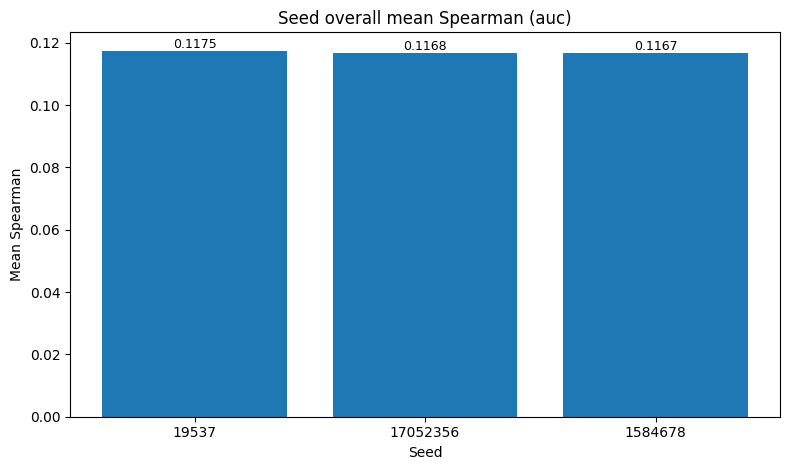

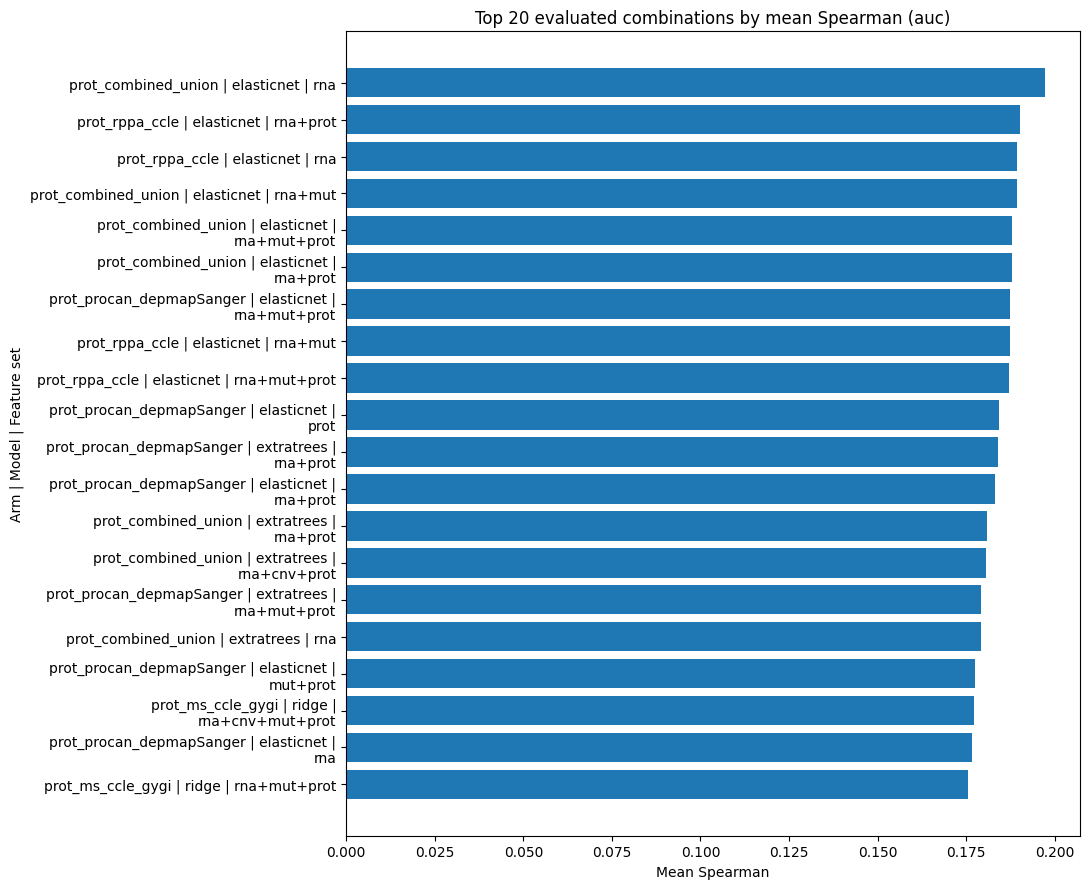

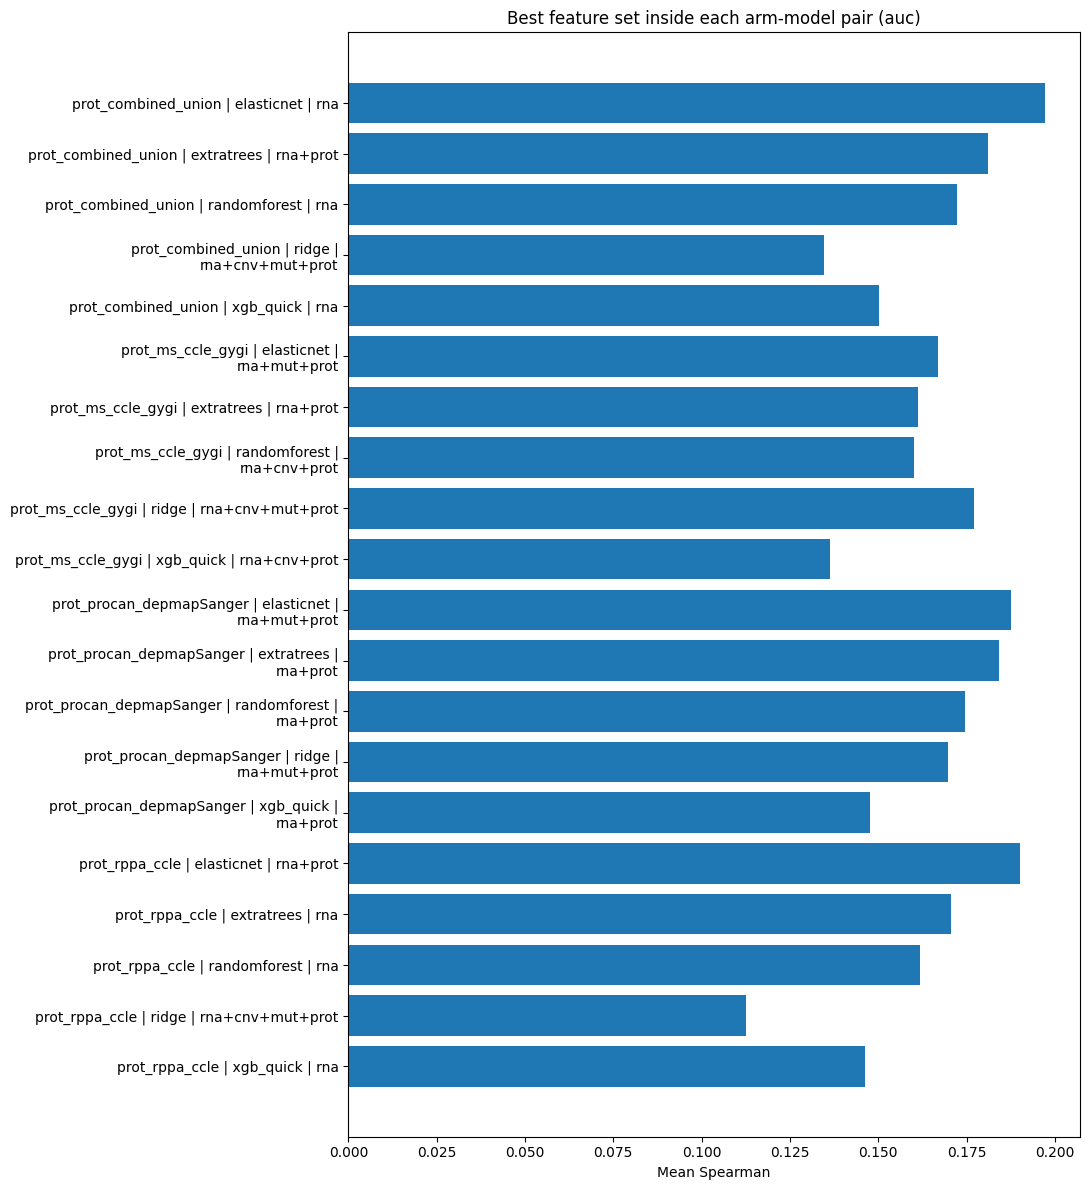

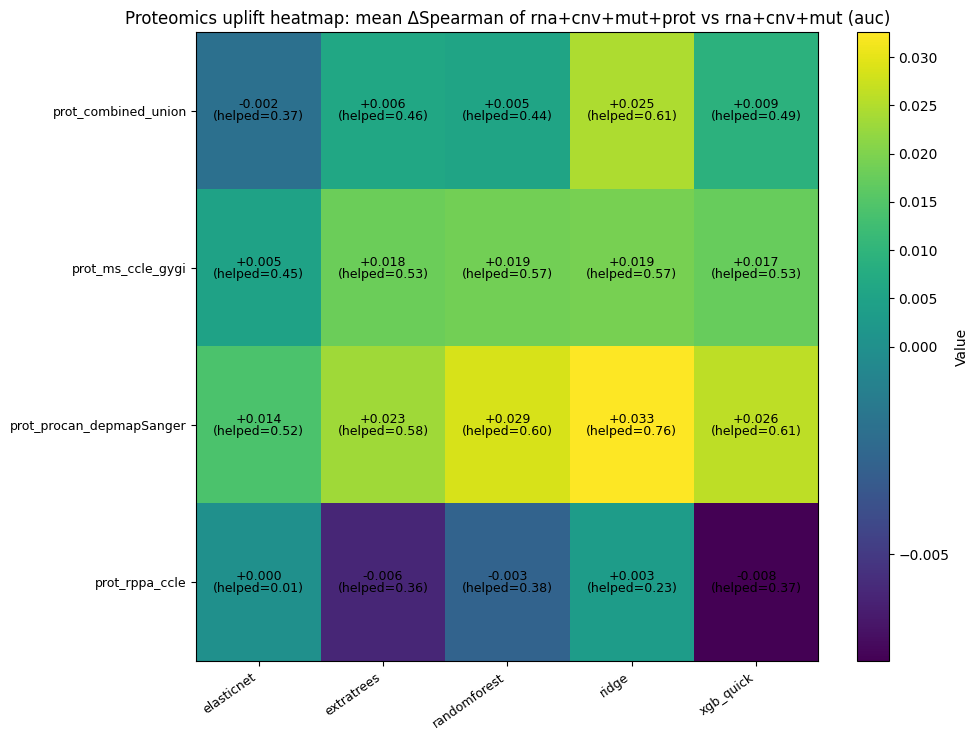

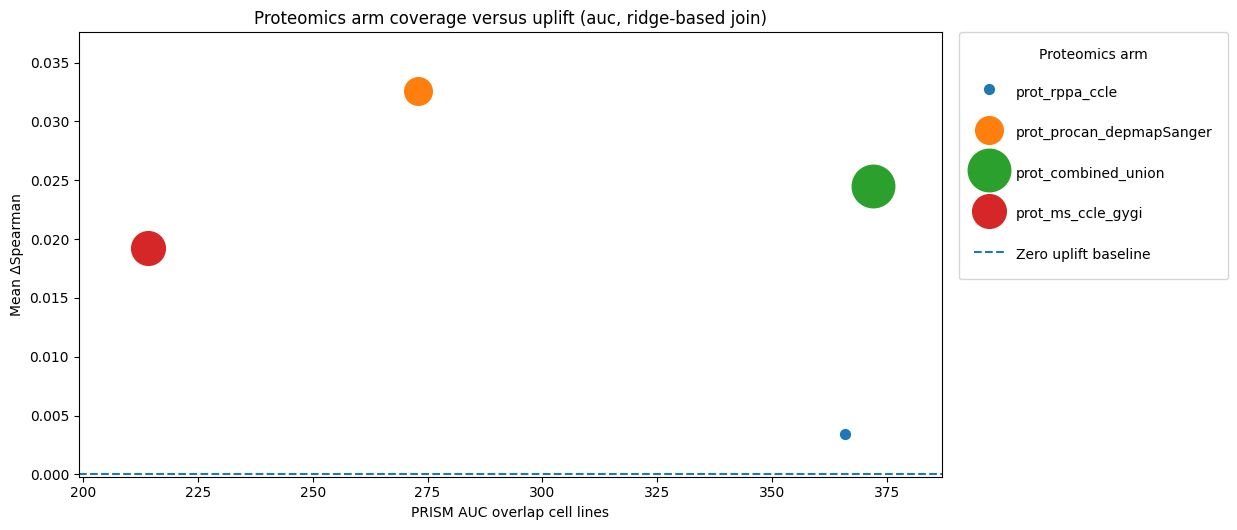

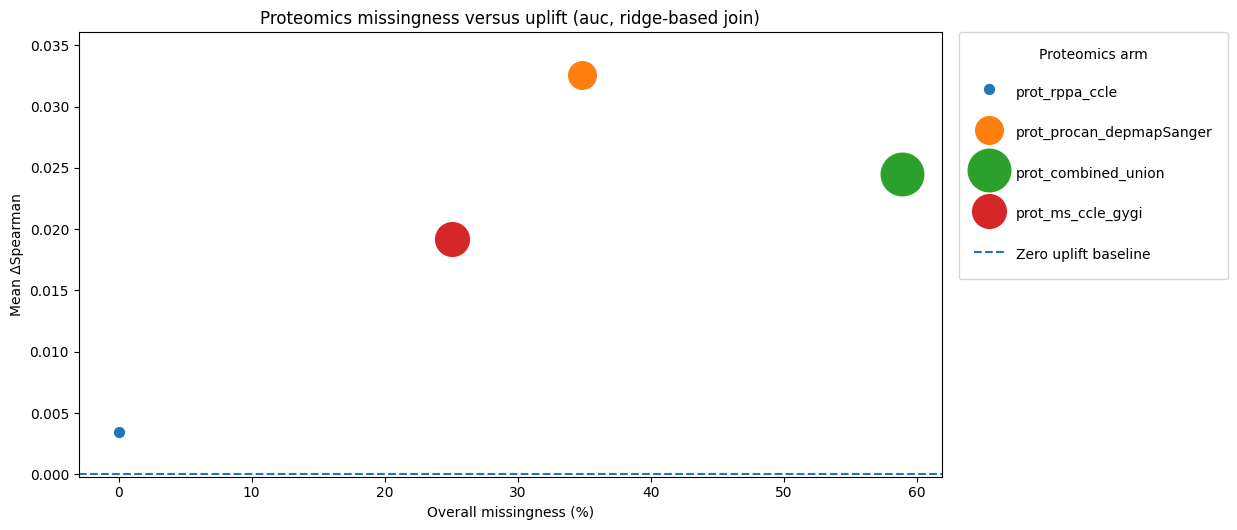

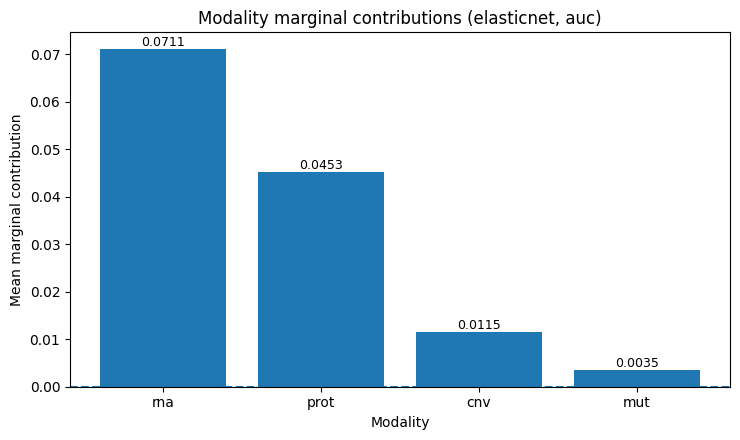

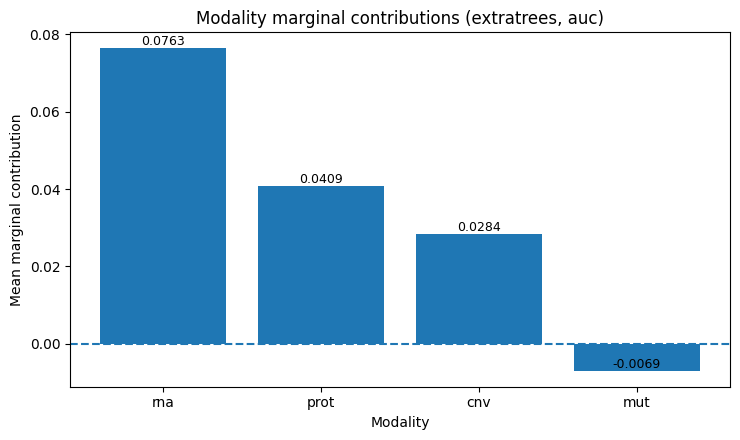

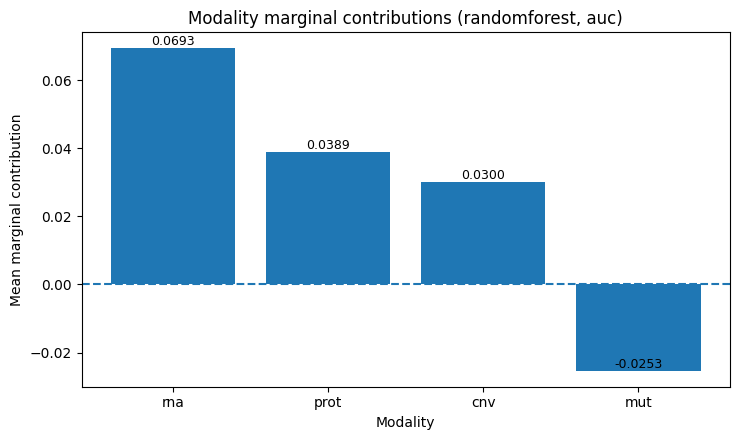

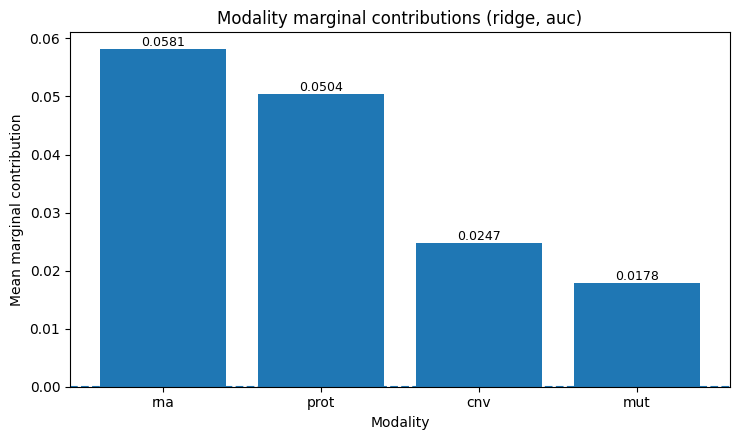

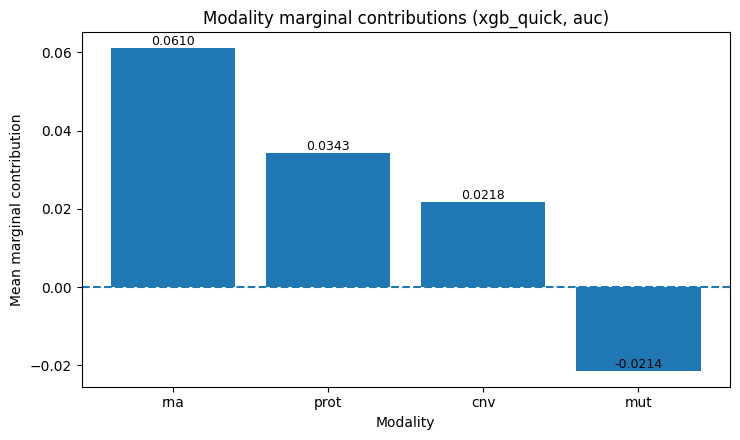

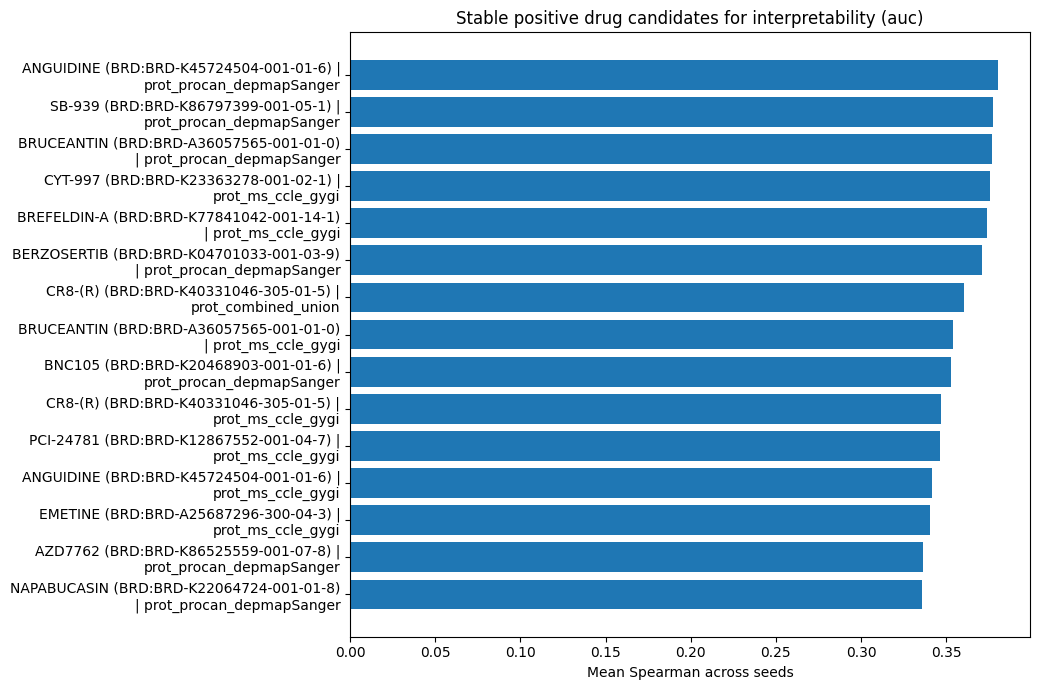

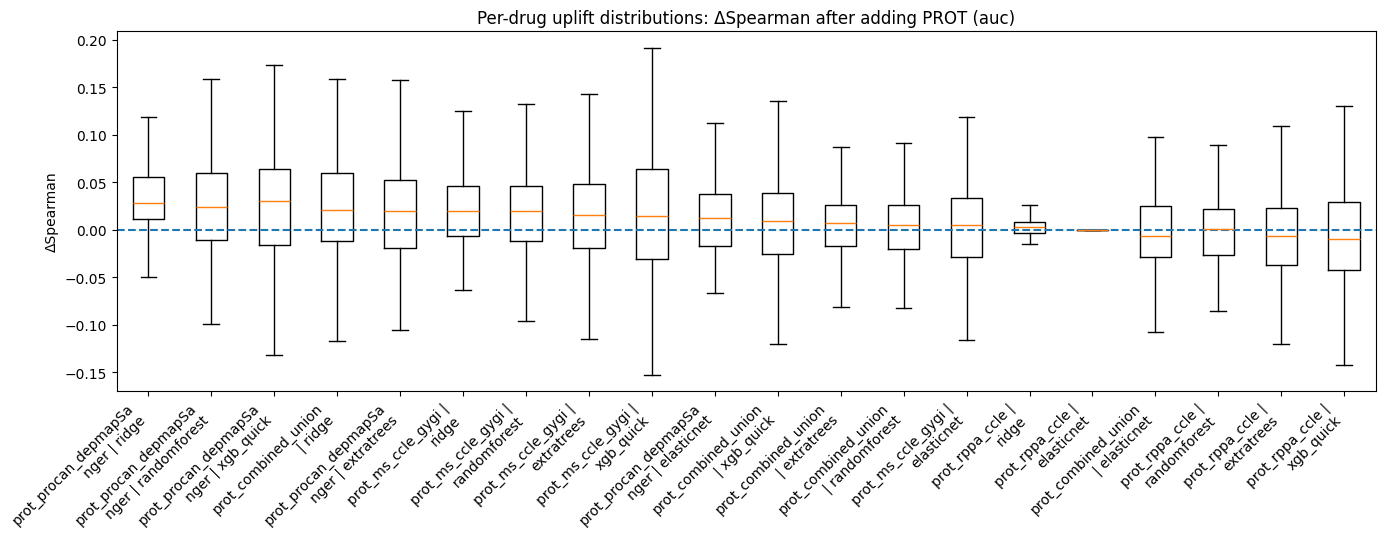


Selected SHAP case study:
{'seed': 1584678, 'arm': 'prot_ms_ccle_gygi', 'model': 'randomforest', 'feature_set': 'rna+cnv+mut+prot', 'compound_id': 'VELBAN (BRD:BRD-K06519765-065-01-6)', 'fold': 8, 'n_test': 11, 'spearman': 0.9727272727272728, 'r2': -0.5500328823800362}
Case-study data: {'split_name': 'GroupKFold(n_splits=10)', 'n_eligible_cells': 304, 'n_train_samples': 200, 'n_test_samples': 11, 'n_features_original': 69135}


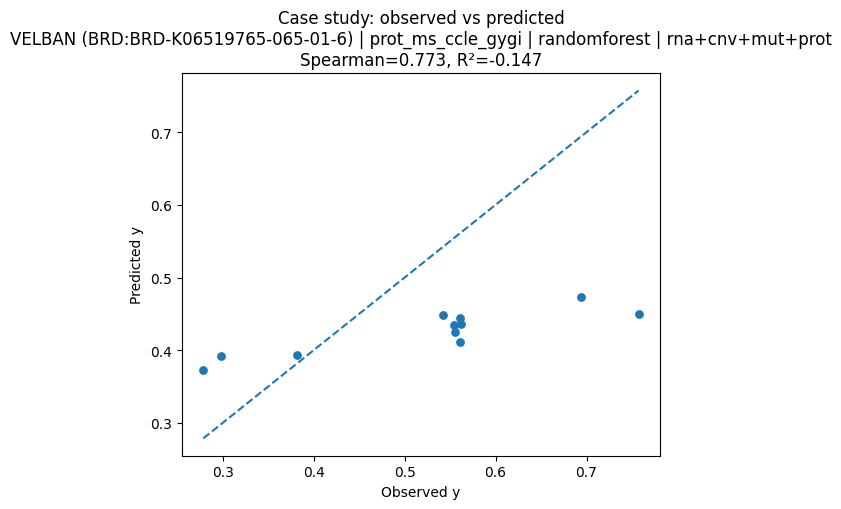

/tmp/ipykernel_5810/1532160820.py:705: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_plot_input, X_test_df, show=False, max_display=25)


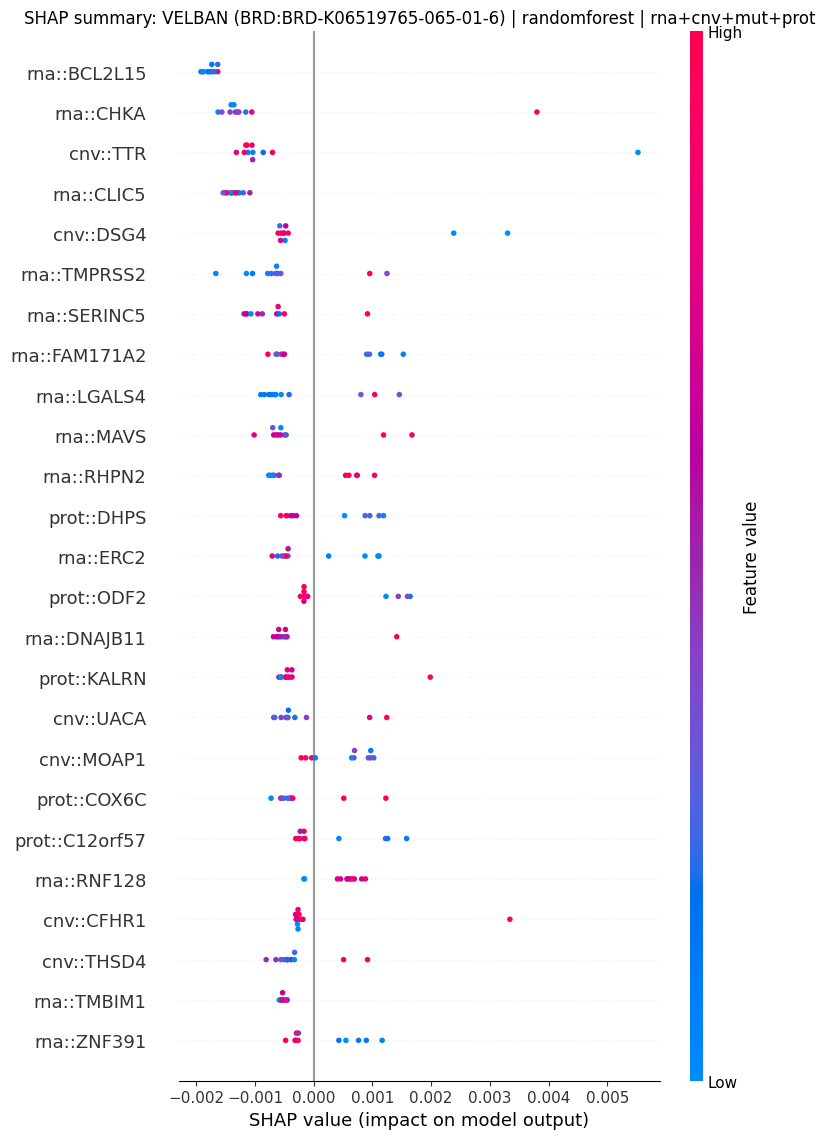

Wrote: artifacts/reports/notebook 3b/interpretability/case__drug_VELBAN_(BRD_BRD-K06519765-065-01-6)__arm_prot_ms_ccle_gygi__model_randomforest__fs_rnapluscnvplusmutplusprot__seed_1584678__fold_8__top_features_by_mean_abs_shap.csv


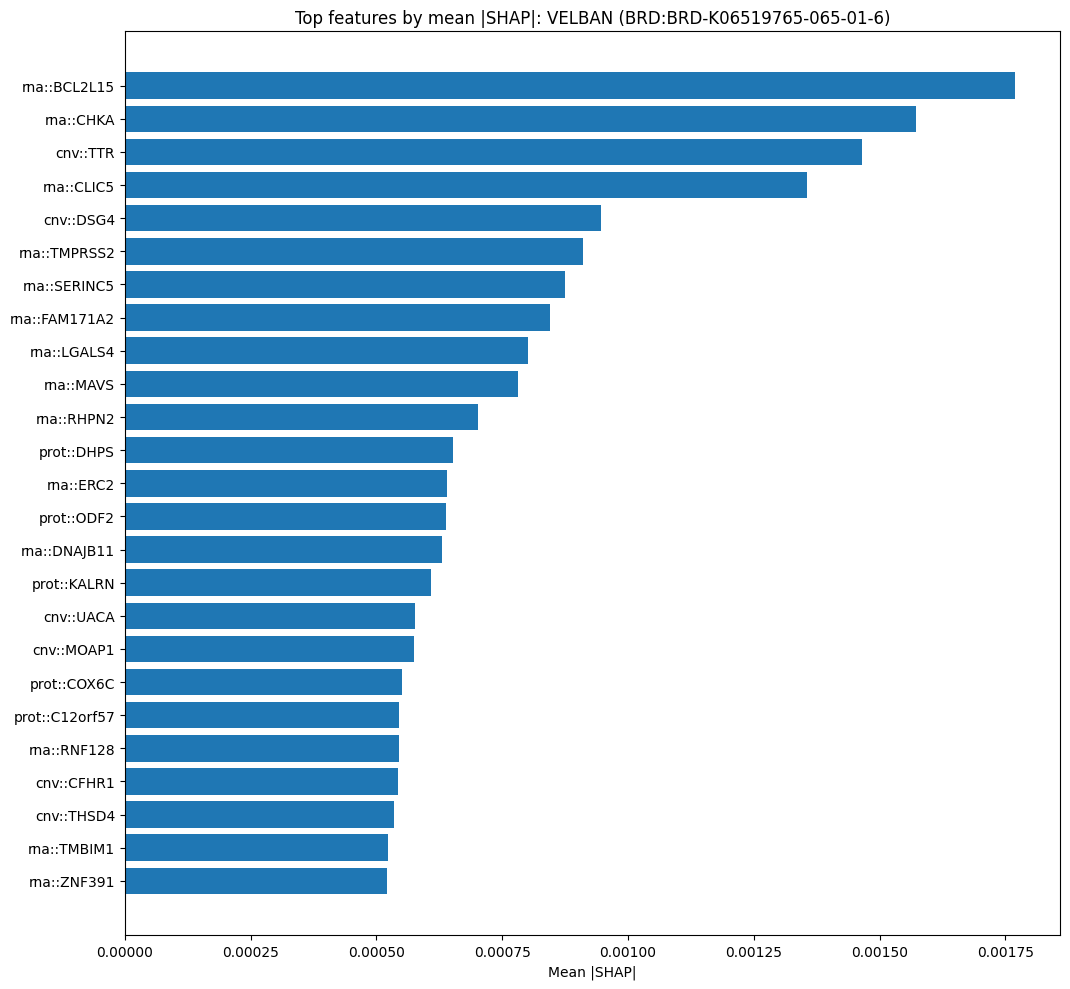

Wrote: artifacts/reports/notebook 3b/interpretability/case__drug_VELBAN_(BRD_BRD-K06519765-065-01-6)__arm_prot_ms_ccle_gygi__model_randomforest__fs_rnapluscnvplusmutplusprot__seed_1584678__fold_8__modality_shap.csv


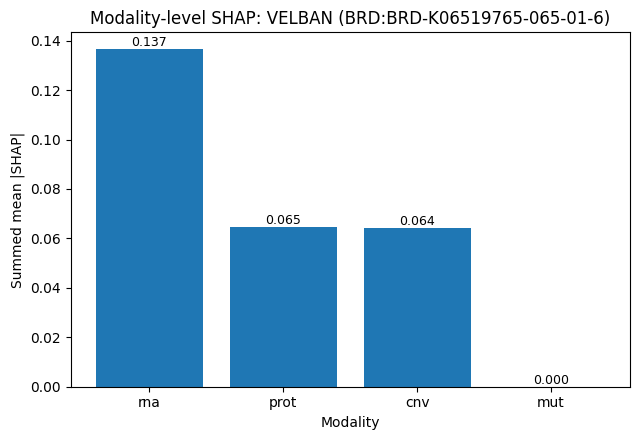

Wrote: artifacts/reports/notebook 3b/interpretability/case__drug_VELBAN_(BRD_BRD-K06519765-065-01-6)__arm_prot_ms_ccle_gygi__model_randomforest__fs_rnapluscnvplusmutplusprot__seed_1584678__fold_8__top_shap_genes.txt
[info] gseapy enrichment unavailable: Invalid organism 'Human'. Valid options are: c. elegans, caenorhabditis elegans, celegans, d. melanogaster, d. rerio, danio rerio, drosophila, drosophila melanogaster, enrichr, fish, fly, h. sapiens, homo sapiens, hs, hsapiens, human, m. musculus, mm, mouse, mus musculus, nematode, s. cerevisiae, saccharomyces, saccharomyces cerevisiae, worm, yeast, zebrafish
[info] Pathway enrichment skipped. No supported enrichment package or no enrichment results.


In [11]:
# Output folders
FIG_DIR = OUT_REPORTS / "figures"
INTERP_DIR = OUT_REPORTS / "interpretability"
FIG_DIR.mkdir(parents=True, exist_ok=True)
INTERP_DIR.mkdir(parents=True, exist_ok=True)


print("Saving evaluation figures to:", FIG_DIR)
print("Saving interpretability outputs to:", INTERP_DIR)


# helpers
def safe_filename(s: str) -> str:
   return (
       str(s)
       .replace("/", "_")
       .replace("\\", "_")
       .replace(" ", "_")
       .replace("+", "plus")
       .replace(":", "_")
       .replace("|", "_")
   )


def wrap_label(s: str, width: int = 24) -> str:
   return "\n".join(textwrap.wrap(str(s), width=width))


def finish_plot(path: Path) -> None:
   plt.tight_layout()
   plt.savefig(path, dpi=170, bbox_inches="tight")
   plt.show()
   plt.close()


def series_from_possible_cols(df: pd.DataFrame, candidates: list[str]) -> Optional[str]:
   cols_lower = {c.lower(): c for c in df.columns}
   for cand in candidates:
       if cand.lower() in cols_lower:
           return cols_lower[cand.lower()]
   return None


def numeric_first_col(df: pd.DataFrame) -> Optional[str]:
   num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
   return num_cols[0] if num_cols else None


def object_first_col(df: pd.DataFrame) -> Optional[str]:
   obj_cols = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]
   return obj_cols[0] if obj_cols else None


def draw_matrix_heatmap(
   mat: pd.DataFrame,
   title: str,
   out_path: Path,
   centre_zero: bool = False,
   annotate_fmt: str = "{:.3f}",
   extra_annot: Optional[pd.DataFrame] = None,
):
   if mat.empty:
       print(f"[skip] {title}: empty matrix")
       return


   arr = mat.to_numpy(dtype=float)
   finite = np.isfinite(arr)
   if not finite.any():
       print(f"[skip] {title}: no finite values")
       return


   vmin = float(np.nanmin(arr))
   vmax = float(np.nanmax(arr))


   plt.figure(figsize=(2.0 * max(4, mat.shape[1]), 1.25 * max(4, mat.shape[0]) + 2.5))
   if centre_zero:
       norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
       im = plt.imshow(arr, aspect="auto", norm=norm)
   else:
       im = plt.imshow(arr, aspect="auto")


   plt.colorbar(im, label="Value")
   plt.xticks(range(mat.shape[1]), [wrap_label(c, 18) for c in mat.columns], rotation=35, ha="right", fontsize=9)
   plt.yticks(range(mat.shape[0]), [wrap_label(i, 24) for i in mat.index], fontsize=9)
   plt.title(title)


   for i in range(mat.shape[0]):
       for j in range(mat.shape[1]):
           val = arr[i, j]
           if np.isfinite(val):
               txt = annotate_fmt.format(val)
               if extra_annot is not None:
                   ev = extra_annot.iloc[i, j]
                   if pd.notna(ev):
                       txt = f"{txt}\n({ev})"
               plt.text(j, i, txt, ha="center", va="center", fontsize=9, linespacing=0.9)

   plt.subplots_adjust(left=0.30, bottom=0.22, right=0.96, top=0.88)
   finish_plot(out_path)


def mean_abs_shap_df(shap_values: np.ndarray, feature_names: list[str]) -> pd.DataFrame:
   m = np.abs(np.asarray(shap_values, dtype=float)).mean(axis=0)
   out = pd.DataFrame({"feature": feature_names, "mean_abs_shap": m})
   out = out.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
   return out


def feature_to_modality(feat: str) -> str:
   feat = str(feat)
   if "::" in feat:
       return feat.split("::", 1)[0]
   return "unknown"


def feature_to_gene(feat: str) -> str:
   feat = str(feat)
   if "::" in feat:
       feat = feat.split("::", 1)[1]
   # for combined union like prot::ms__TP53
   if "__" in feat:
       feat = feat.split("__")[-1]
   # light cleanup
   feat = re.sub(r"[^A-Za-z0-9\-_]", "", feat)
   return feat


def load_detail_rows_for_seeds(out_dir: Path, seeds: List[int]) -> pd.DataFrame:
   dfs = []


   for s in seeds:
       fp = set_paths_for_seed(s)["detail"]
       if not fp.exists():
           print("Missing detail file:", fp)
           continue


       df = pd.read_csv(fp)


       if "seed" not in df.columns or df["seed"].isna().all():
           df["seed"] = s


       df["seed"] = pd.to_numeric(df["seed"], errors="coerce")
       df = df.dropna(subset=["seed"]).copy()
       df["seed"] = df["seed"].astype(int)
       df = df[df["seed"].isin(seeds)].copy()


       for c in ["spearman", "r2", "n_train", "n_test", "fold"]:
           if c in df.columns:
               df[c] = pd.to_numeric(df[c], errors="coerce")


       dfs.append(df)


   if not dfs:
       raise FileNotFoundError("No detail benchmark files found for the requested seeds.")


   return pd.concat(dfs, ignore_index=True).drop_duplicates()


detail_merged = load_detail_rows_for_seeds(OUT_REPORTS, ALL_SEEDS)
print("Loaded detail rows for SHAP case study:", detail_merged.shape)


# Seed-level summary graph
if "seed_overall" in globals() and isinstance(seed_overall, pd.DataFrame) and seed_overall.shape[0] > 0:
   tmp = seed_overall.sort_values("mean_spearman", ascending=False).copy()


   plt.figure(figsize=(8, 4.8))
   plt.bar(tmp["seed"].astype(str), tmp["mean_spearman"])
   for i, v in enumerate(tmp["mean_spearman"].tolist()):
       plt.text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9)
   plt.title(f"Seed overall mean Spearman ({PRIMARY_TARGET})")
   plt.xlabel("Seed")
   plt.ylabel("Mean Spearman")
   finish_plot(FIG_DIR / f"seed_overall_mean_spearman_{PRIMARY_TARGET}.png")


# Top combinations overall
if "feature_combo_ranking" in globals() and isinstance(feature_combo_ranking, pd.DataFrame) and feature_combo_ranking.shape[0] > 0:
   topk = feature_combo_ranking.head(20).copy()
   topk["label"] = (
       topk["arm"].astype(str)
       + " | "
       + topk["model"].astype(str)
       + " | "
       + topk["feature_set"].astype(str)
   )


   plt.figure(figsize=(11, max(6, int(0.42 * len(topk) + 1))))
   plt.barh(range(len(topk)), topk["mean_spearman"])
   plt.yticks(range(len(topk)), [wrap_label(x, 42) for x in topk["label"]])
   plt.gca().invert_yaxis()
   plt.title(f"Top 20 evaluated combinations by mean Spearman ({PRIMARY_TARGET})")
   plt.xlabel("Mean Spearman")
   plt.ylabel("Arm | Model | Feature set")
   finish_plot(FIG_DIR / f"top20_feature_combinations_{PRIMARY_TARGET}.png")


# Best combination per arm-model
if "feature_combo_ranking" in globals() and isinstance(feature_combo_ranking, pd.DataFrame) and feature_combo_ranking.shape[0] > 0:
   best_arm_model = (
       feature_combo_ranking
       .sort_values(["arm", "model", "mean_spearman"], ascending=[True, True, False])
       .groupby(["arm", "model"], as_index=False)
       .head(1)
       .reset_index(drop=True)
   )
   best_arm_model["label"] = best_arm_model["arm"] + " | " + best_arm_model["model"] + " | " + best_arm_model["feature_set"]


   plt.figure(figsize=(11, max(6, int(0.55 * len(best_arm_model) + 1))))
   plt.barh(range(len(best_arm_model)), best_arm_model["mean_spearman"])
   plt.yticks(range(len(best_arm_model)), [wrap_label(x, 44) for x in best_arm_model["label"]])
   plt.gca().invert_yaxis()
   plt.title(f"Best feature set inside each arm-model pair ({PRIMARY_TARGET})")
   plt.xlabel("Mean Spearman")
   finish_plot(FIG_DIR / f"best_by_arm_model_{PRIMARY_TARGET}.png")


# Proteomics uplift heatmap
if "uplift_summary" in globals() and isinstance(uplift_summary, pd.DataFrame) and uplift_summary.shape[0] > 0:
   hm = uplift_summary.pivot(index="arm", columns="model", values="mean_delta_sp")
   ann = uplift_summary.copy()
   ann["label"] = (
       ann["frac_helped"].fillna(0.0).map(lambda x: f"helped={x:.2f}")
   )
   ann_mat = ann.pivot(index="arm", columns="model", values="label").reindex(index=hm.index, columns=hm.columns)


   draw_matrix_heatmap(
       hm,
       title=f"Proteomics uplift heatmap: mean ΔSpearman of rna+cnv+mut+prot vs rna+cnv+mut ({PRIMARY_TARGET})",
       out_path=FIG_DIR / f"uplift_heatmap_mean_delta_spearman_{PRIMARY_TARGET}.png",
       centre_zero=True,
       annotate_fmt="{:+.3f}",
       extra_annot=ann_mat,
   )


# Coverage versus performance
if "cov_perf" in globals() and isinstance(cov_perf, pd.DataFrame) and cov_perf.shape[0] > 0:
    # Coverage versus uplift
    plt.figure(figsize=(12.5, 5.4))

    xcol = "n_overlap_with_prism_auc_cells"
    ycol = "mean_delta_sp"

    xvals = cov_perf[xcol].to_numpy(dtype=float)
    yvals = cov_perf[ycol].to_numpy(dtype=float)

    for arm, sub in cov_perf.groupby("arm", sort=False):
        plt.scatter(
            sub[xcol].to_numpy(dtype=float),
            sub[ycol].to_numpy(dtype=float),
            s=np.maximum(50, sub["n_features"].fillna(0).to_numpy(dtype=float) / 20.0),
            label=str(arm),
        )

    plt.axhline(0.0, linestyle="--", label="Zero uplift baseline")

    xpad = 15
    ypad = 0.005
    plt.xlim(xvals.min() - xpad, xvals.max() + xpad)
    plt.ylim(min(-0.0002, yvals.min() - 0.0004), yvals.max() + ypad)

    plt.title(f"Proteomics arm coverage versus uplift ({PRIMARY_TARGET}, ridge-based join)")
    plt.xlabel("PRISM AUC overlap cell lines")
    plt.ylabel("Mean ΔSpearman")

    plt.legend(
        title="Proteomics arm",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
        frameon=True,
        labelspacing=1.5,
        borderpad=1.1,
        handlelength=2.2,
        handleheight=1.8,
        handletextpad=0.8,
    )

    finish_plot(FIG_DIR / f"coverage_vs_uplift_{PRIMARY_TARGET}.png")

    # Missingness versus uplift
    plt.figure(figsize=(12.5, 5.4))

    xcol = "overall_missing_pct"
    ycol = "mean_delta_sp"

    xvals = cov_perf[xcol].to_numpy(dtype=float)
    yvals = cov_perf[ycol].to_numpy(dtype=float)

    for arm, sub in cov_perf.groupby("arm", sort=False):
        plt.scatter(
            sub[xcol].to_numpy(dtype=float),
            sub[ycol].to_numpy(dtype=float),
            s=np.maximum(50, sub["n_features"].fillna(0).to_numpy(dtype=float) / 20.0),
            label=str(arm),
        )

    plt.axhline(0.0, linestyle="--", label="Zero uplift baseline")

    xpad_left = 3.0
    xpad_right = 3.0
    ypad_bottom = 0.0004
    ypad_top = 0.0035

    plt.xlim(xvals.min() - xpad_left, xvals.max() + xpad_right)
    plt.ylim(
        min(-0.0002, yvals.min() - ypad_bottom),
        yvals.max() + ypad_top
    )

    plt.title(f"Proteomics missingness versus uplift ({PRIMARY_TARGET}, ridge-based join)")
    plt.xlabel("Overall missingness (%)")
    plt.ylabel("Mean ΔSpearman")

    plt.legend(
        title="Proteomics arm",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
        frameon=True,
        labelspacing=1.5,
        borderpad=1.1,
        handlelength=2.2,
        handleheight=1.8,
        handletextpad=0.8,
    )

    finish_plot(FIG_DIR / f"missingness_vs_uplift_{PRIMARY_TARGET}.png")


# Modality marginal contributions
if "shapley_df" in globals() and isinstance(shapley_df, pd.DataFrame) and shapley_df.shape[0] > 0:
   for mdl in sorted(shapley_df["model"].dropna().unique().tolist()):
       sub = shapley_df[shapley_df["model"] == mdl].copy()
       sub = sub.sort_values("mean_marginal_contribution", ascending=False)


       plt.figure(figsize=(7.5, 4.5))
       plt.bar(sub["modality"], sub["mean_marginal_contribution"])
       for i, v in enumerate(sub["mean_marginal_contribution"].tolist()):
           plt.text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9)
       plt.axhline(0.0, linestyle="--")
       plt.title(f"Modality marginal contributions ({mdl}, {PRIMARY_TARGET})")
       plt.xlabel("Modality")
       plt.ylabel("Mean marginal contribution")
       finish_plot(FIG_DIR / f"modality_marginal_contributions__{safe_filename(mdl)}__{PRIMARY_TARGET}.png")


# Stable drug candidates
if "stable_candidates" in globals() and isinstance(stable_candidates, pd.DataFrame) and stable_candidates.shape[0] > 0:
   tmp = stable_candidates.head(15).copy()
   tmp["label"] = tmp["compound_id"].astype(str) + " | " + tmp["arm"].astype(str)


   plt.figure(figsize=(10.5, max(5, int(0.42 * len(tmp) + 1))))
   plt.barh(range(len(tmp)), tmp["mean_spearman"])
   plt.yticks(range(len(tmp)), [wrap_label(x, 40) for x in tmp["label"]])
   plt.gca().invert_yaxis()
   plt.title(f"Stable positive drug candidates for interpretability ({PRIMARY_TARGET})")
   plt.xlabel("Mean Spearman across seeds")
   finish_plot(FIG_DIR / f"stable_positive_drugs_{PRIMARY_TARGET}.png")


# Drug uplift distribution by arm-model
if "per_drug_uplift" in globals() and isinstance(per_drug_uplift, pd.DataFrame) and per_drug_uplift.shape[0] > 0:
   combo_order = (
       uplift_summary
       .sort_values("mean_delta_sp", ascending=False)
       .assign(combo=lambda d: d["arm"] + " | " + d["model"])
       ["combo"]
       .tolist()
       if "uplift_summary" in globals() and uplift_summary.shape[0] > 0
       else None
   )


   tmp = per_drug_uplift.copy()
   tmp["combo"] = tmp["arm"] + " | " + tmp["model"]
   if combo_order is not None:
       tmp["combo"] = pd.Categorical(tmp["combo"], categories=combo_order, ordered=True)
       tmp = tmp.sort_values("combo")


   groups = list(tmp.groupby("combo", sort=False, observed=False))
   if len(groups) > 0:
       labels = [str(k) for k, _ in groups]
       data = [g["delta_spearman"].dropna().to_numpy(dtype=float) for _, g in groups]


       plt.figure(figsize=(max(10, int(0.62 * len(labels) + 2)), 5.6))
       plt.boxplot(data, tick_labels=[wrap_label(x, 20) for x in labels], showfliers=False)
       plt.axhline(0.0, linestyle="--")
       plt.title(f"Per-drug uplift distributions: ΔSpearman after adding PROT ({PRIMARY_TARGET})")
       plt.ylabel("ΔSpearman")
       plt.xticks(rotation=45, ha="right")
       finish_plot(FIG_DIR / f"per_drug_uplift_boxplots_{PRIMARY_TARGET}.png")


# SHAP case study for one tree-based proteomics result
#   Important:
#   - This notebook uses PCA in the benchmark.
#   - SHAP on PCA components is not biologically useful.
#   - So for interpretability we refit ONE case-study model on original
#     fold-safe features without PCA, using the same train/test fold.
TREE_MODELS = {"extratrees", "randomforest", "xgb_quick"}


def make_tree_model_for_case(model_name: str, seed: int):
   model_name = str(model_name).lower()
   if model_name == "extratrees":
       return ExtraTreesRegressor(
           n_estimators=ET_N_ESTIMATORS,
           random_state=seed,
           n_jobs=-1,
           max_depth=ET_MAX_DEPTH,
           min_samples_leaf=ET_MIN_SAMPLES_LEAF,
       )
   if model_name == "randomforest":
       return RandomForestRegressor(
           n_estimators=RF_N_ESTIMATORS,
           random_state=seed,
           n_jobs=-1,
           max_depth=RF_MAX_DEPTH,
           min_samples_leaf=RF_MIN_SAMPLES_LEAF,
       )
   if model_name == "xgb_quick":
       set_seeds(seed)
       mdl, _ = try_make_xgb()
       return mdl
   raise ValueError(f"Unsupported SHAP case-study model: {model_name}")


def fit_original_imputed_frame(train_df: pd.DataFrame, all_df: pd.DataFrame, prefix: str) -> pd.DataFrame:
   train_df = train_df.copy()
   all_df = all_df.copy()


   keep = train_df.notna().any(axis=0)
   if int(keep.sum()) == 0:
       return pd.DataFrame(index=all_df.index)


   train_k = train_df.loc[:, keep]
   all_k = all_df.loc[:, keep]


   imp = SimpleImputer(strategy="median")
   all_imp = imp.fit(train_k).transform(all_k)


   cols = [f"{prefix}::{c}" for c in train_k.columns.astype(str)]
   out = pd.DataFrame(all_imp, index=all_df.index, columns=cols)
   return out


def build_case_study_dataset(case_seed: int, case_arm: str, case_drug: str, case_fold: int, case_feature_set: str):
   set_seeds(case_seed)


   prot_df = proteomics_arms[case_arm].copy()
   prot_df.index = prot_df.index.astype(str).str.strip()
   prot_core = prot_df.reindex(core_cells)


   has_prot = has_any_observation(prot_core)
   eligible_cells = sorted(has_prot[has_prot].index.tolist())


   arm_groups = groups_all.reindex(eligible_cells).fillna("Unknown").astype(str)
   splits, split_name = safe_group_splits(eligible_cells, arm_groups, N_SPLITS_DESIRED)


   fold_i = int(case_fold)
   train_idx_split, test_idx_split = splits[fold_i]
   train_cells_split = [eligible_cells[int(j)] for j in train_idx_split]
   test_cells_split = [eligible_cells[int(j)] for j in test_idx_split]
   train_cell_set = set(train_cells_split)
   test_cell_set = set(test_cells_split)


   case_drug = str(case_drug).strip()


   pairs = prism_auc.loc[
       prism_auc["compound_id"].astype(str).str.strip().eq(case_drug),
       ["depmap_id", "y"]
   ].copy()


   if pairs.shape[0] == 0:
       available = prism_auc["compound_id"].astype(str).str.strip().unique().tolist()
       raise KeyError(
           f"Case-study drug not found in prism_auc: {case_drug!r}. "
           f"Example available drugs: {available[:10]}"
       )


   pairs["depmap_id"] = pairs["depmap_id"].astype(str).str.strip()
   pairs = (
       pairs[pairs["depmap_id"].isin(eligible_cells)]
       .groupby("depmap_id", as_index=False)["y"]
       .mean()
   )


   pair_cells = pairs["depmap_id"].tolist()
   train_sample_cells = [c for c in pair_cells if c in train_cell_set]
   test_sample_cells = [c for c in pair_cells if c in test_cell_set]


   if len(train_sample_cells) == 0 or len(test_sample_cells) == 0:
       raise RuntimeError("Selected SHAP case study has no usable train/test cells.")


   y_lookup = pairs.set_index("depmap_id")["y"]


   combo_keys = tuple(str(case_feature_set).split("+"))
   frames = []


   for mod in combo_keys:
       if mod == "rna":
           frames.append(
               fit_original_imputed_frame(
                   train_df=rna.loc[train_cells_split],
                   all_df=rna.loc[eligible_cells],
                   prefix="rna",
               )
           )
       elif mod == "cnv":
           frames.append(
               fit_original_imputed_frame(
                   train_df=cnv.loc[train_cells_split],
                   all_df=cnv.loc[eligible_cells],
                   prefix="cnv",
               )
           )
       elif mod == "mut":
           frames.append(
               fit_original_imputed_frame(
                   train_df=mut.loc[train_cells_split].astype(float),
                   all_df=mut.loc[eligible_cells].astype(float),
                   prefix="mut",
               )
           )
       elif mod == "prot":
           frames.append(
               fit_original_imputed_frame(
                   train_df=prot_core.loc[train_cells_split],
                   all_df=prot_core.loc[eligible_cells],
                   prefix="prot",
               )
           )
       else:
           raise ValueError(f"Unknown modality in case feature set: {mod}")


   X_all_df = pd.concat(frames, axis=1)
   X_train_df = X_all_df.loc[train_sample_cells]
   X_test_df = X_all_df.loc[test_sample_cells]
   y_train = y_lookup.loc[train_sample_cells].to_numpy(dtype=float)
   y_test = y_lookup.loc[test_sample_cells].to_numpy(dtype=float)


   meta = {
       "split_name": split_name,
       "n_eligible_cells": len(eligible_cells),
       "n_train_samples": len(train_sample_cells),
       "n_test_samples": len(test_sample_cells),
       "n_features_original": X_all_df.shape[1],
   }
   return X_train_df, X_test_df, y_train, y_test, meta


def plot_shap_case_study():
   if "detail_merged" not in globals() or detail_merged.shape[0] == 0:
       print("[skip] SHAP case study: detail-level results are unavailable")
       return


   case_pool = detail_merged[
       detail_merged["model"].isin(TREE_MODELS)
       & detail_merged["feature_set"].astype(str).str.contains(r"(?:^|\+)prot(?:\+|$)", regex=True)
   ].copy()


   if case_pool.shape[0] == 0:
       print("[skip] SHAP case study: no tree-based proteomics fold rows found")
       return


   case_row = (
       case_pool
       .sort_values(["spearman", "r2", "n_test"], ascending=[False, False, False])
       .iloc[0]
   )


   case_seed = int(case_row["seed"])
   case_arm = str(case_row["arm"])
   case_model = str(case_row["model"])
   case_feature_set = str(case_row["feature_set"])
   case_drug = str(case_row["compound_id"])
   case_fold = int(case_row["fold"])


   print("\nSelected SHAP case study:")
   print({
       "seed": case_seed,
       "arm": case_arm,
       "model": case_model,
       "feature_set": case_feature_set,
       "compound_id": case_drug,
       "fold": case_fold,
       "n_test": int(case_row["n_test"]),
       "spearman": float(case_row["spearman"]),
       "r2": float(case_row["r2"]),
   })


   X_train_df, X_test_df, y_train, y_test, meta = build_case_study_dataset(
       case_seed=case_seed,
       case_arm=case_arm,
       case_drug=case_drug,
       case_fold=case_fold,
       case_feature_set=case_feature_set,
   )


   print("Case-study data:", meta)


   mdl = make_tree_model_for_case(case_model, case_seed)
   mdl.fit(X_train_df, y_train)
   pred = mdl.predict(X_test_df)


   case_prefix = (
       f"case__drug_{safe_filename(case_drug)}"
       f"__arm_{safe_filename(case_arm)}"
       f"__model_{safe_filename(case_model)}"
       f"__fs_{safe_filename(case_feature_set)}"
       f"__seed_{case_seed}"
       f"__fold_{case_fold}"
   )


   # Predicted vs observed
   plt.figure(figsize=(5.6, 5.2))
   plt.scatter(y_test, pred, s=28)
   lo = min(np.min(y_test), np.min(pred))
   hi = max(np.max(y_test), np.max(pred))
   plt.plot([lo, hi], [lo, hi], linestyle="--")
   plt.title(
       f"Case study: observed vs predicted\n"
       f"{case_drug} | {case_arm} | {case_model} | {case_feature_set}\n"
       f"Spearman={spearman_corr(y_test, pred):.3f}, R²={r2_score(y_test, pred):.3f}"
   )
   plt.xlabel("Observed y")
   plt.ylabel("Predicted y")
   finish_plot(INTERP_DIR / f"{case_prefix}__pred_vs_obs.png")


   try:
       try:
           explainer = shap.TreeExplainer(mdl)
           try:
               shap_out = explainer(X_test_df)
               shap_values = shap_out.values if hasattr(shap_out, "values") else np.asarray(shap_out)
               shap_plot_input = shap_out
           except Exception:
               shap_values = explainer.shap_values(X_test_df)
               shap_plot_input = shap_values
       except Exception as e:
           print("[skip] SHAP TreeExplainer failed:", e)
           return


       shap_values = np.asarray(shap_values, dtype=float)
       if shap_values.ndim == 1:
           shap_values = shap_values.reshape(1, -1)


       # Beeswarm / summary plot
       try:
           shap.summary_plot(shap_plot_input, X_test_df, show=False, max_display=25)
       except Exception:
           shap.summary_plot(shap_values, X_test_df, show=False, max_display=25)
       plt.title(f"SHAP summary: {case_drug} | {case_model} | {case_feature_set}")
       finish_plot(INTERP_DIR / f"{case_prefix}__shap_summary.png")


       # Mean absolute SHAP
       shap_top = mean_abs_shap_df(shap_values, X_test_df.columns.tolist())
       shap_top_path = INTERP_DIR / f"{case_prefix}__top_features_by_mean_abs_shap.csv"
       shap_top.to_csv(shap_top_path, index=False)
       print("Wrote:", shap_top_path)


       top25 = shap_top.head(25).copy()
       plt.figure(figsize=(10.8, max(5, int(0.38 * len(top25) + 1))))
       plt.barh(range(len(top25)), top25["mean_abs_shap"])
       plt.yticks(range(len(top25)), [wrap_label(x, 48) for x in top25["feature"]])
       plt.gca().invert_yaxis()
       plt.title(f"Top features by mean |SHAP|: {case_drug}")
       plt.xlabel("Mean |SHAP|")
       finish_plot(INTERP_DIR / f"{case_prefix}__top25_mean_abs_shap.png")


       # Modality-level SHAP aggregation
       shap_top["modality"] = shap_top["feature"].map(feature_to_modality)
       modality_shap = (
           shap_top.groupby("modality", as_index=False)["mean_abs_shap"]
           .sum()
           .sort_values("mean_abs_shap", ascending=False)
       )
       modality_shap_path = INTERP_DIR / f"{case_prefix}__modality_shap.csv"
       modality_shap.to_csv(modality_shap_path, index=False)
       print("Wrote:", modality_shap_path)


       plt.figure(figsize=(6.5, 4.5))
       plt.bar(modality_shap["modality"], modality_shap["mean_abs_shap"])
       for i, v in enumerate(modality_shap["mean_abs_shap"].tolist()):
           plt.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
       plt.title(f"Modality-level SHAP: {case_drug}")
       plt.xlabel("Modality")
       plt.ylabel("Summed mean |SHAP|")
       finish_plot(INTERP_DIR / f"{case_prefix}__modality_shap.png")


       # Pathway enrichment from top SHAP genes
       top_genes = [feature_to_gene(f) for f in shap_top["feature"].head(100).tolist()]
       top_genes = [g for g in top_genes if isinstance(g, str) and len(g) >= 2]
       top_genes = list(dict.fromkeys(top_genes))[:100]


       genes_path = INTERP_DIR / f"{case_prefix}__top_shap_genes.txt"
       with genes_path.open("w", encoding="utf-8") as f:
           for g in top_genes:
               f.write(f"{g}\n")
       print("Wrote:", genes_path)


       enrichment_done = False


       # gprofiler
       try:
           if len(top_genes) >= 5 and "HAS_GPROFILER" in globals() and HAS_GPROFILER:
               gp_client = GProfiler(return_dataframe=True)
               enr = gp_client.profile(
                   organism="hsapiens",
                   query=top_genes,
                   sources=["GO:BP", "REAC"],
               )
               if enr is not None and enr.shape[0] > 0:
                   enr = enr.sort_values("p_value", ascending=True).head(20).copy()
                   enr["minus_log10_p"] = -np.log10(enr["p_value"].clip(lower=1e-300))
                   out_csv = INTERP_DIR / f"{case_prefix}__pathway_enrichment_gprofiler.csv"
                   enr.to_csv(out_csv, index=False)
                   print("Wrote:", out_csv)


                   plot_df = enr.sort_values("minus_log10_p", ascending=True).tail(15)
                   plt.figure(figsize=(11, max(5, int(0.35 * len(plot_df) + 1))))
                   plt.barh(range(len(plot_df)), plot_df["minus_log10_p"])
                   labels = [f"{a} | {b}" for a, b in zip(plot_df["source"], plot_df["name"])]
                   plt.yticks(range(len(plot_df)), [wrap_label(x, 48) for x in labels])
                   plt.title(f"Pathway enrichment from top SHAP genes: {case_drug}")
                   plt.xlabel("-log10(p-value)")
                   finish_plot(INTERP_DIR / f"{case_prefix}__pathway_enrichment.png")
                   enrichment_done = True
       except Exception as e:
           print("[info] gProfiler enrichment unavailable:", e)


       # gseapy enrichr fallback
       if not enrichment_done:
           try:
               if len(top_genes) >= 5:
                   enr_obj = gp.enrichr(
                       gene_list=top_genes,
                       gene_sets=["GO_Biological_Process_2023", "Reactome_2022"],
                       organism="Human",
                       outdir=None,
                   )
                   enr = enr_obj.results.copy()
                   if enr.shape[0] > 0:
                       pcol = "Adjusted P-value" if "Adjusted P-value" in enr.columns else "P-value"
                       tcol = "Term" if "Term" in enr.columns else enr.columns[0]
                       enr = enr.sort_values(pcol, ascending=True).head(20).copy()
                       enr["minus_log10_p"] = -np.log10(pd.to_numeric(enr[pcol], errors="coerce").clip(lower=1e-300))
                       out_csv = INTERP_DIR / f"{case_prefix}__pathway_enrichment_gseapy.csv"
                       enr.to_csv(out_csv, index=False)
                       print("Wrote:", out_csv)


                       plot_df = enr.sort_values("minus_log10_p", ascending=True).tail(15)
                       plt.figure(figsize=(11, max(5, int(0.35 * len(plot_df) + 1))))
                       plt.barh(range(len(plot_df)), plot_df["minus_log10_p"])
                       plt.yticks(range(len(plot_df)), [wrap_label(x, 48) for x in plot_df[tcol].astype(str).tolist()])
                       plt.title(f"Pathway enrichment from top SHAP genes: {case_drug}")
                       plt.xlabel("-log10(adjusted p-value)")
                       finish_plot(INTERP_DIR / f"{case_prefix}__pathway_enrichment.png")
                       enrichment_done = True
           except Exception as e:
               print("[info] gseapy enrichment unavailable:", e)


       if not enrichment_done:
           print("[info] Pathway enrichment skipped. No supported enrichment package or no enrichment results.")


   except Exception as e:
       print("[skip] SHAP case study failed:", e)

plot_shap_case_study()

def glob_many(root: Path, patterns: list[str]) -> list[Path]:
   hits = []
   for pat in patterns:
       hits.extend(list(root.glob(pat)))
   # unique while preserving order
   uniq = []
   seen = set()
   for p in hits:
       rp = str(p.resolve())
       if rp not in seen:
           uniq.append(p)
           seen.add(rp)
   return uniq


def plot_optional_attribution_artifact(kind: str, patterns: list[str], top_n: int = 20):
   hits = glob_many(ARTIFACTS, patterns)
   if len(hits) == 0:
       print(f"[info] No {kind} artefact files found under artifacts/reports/")
       return


   latest = sorted(hits, key=lambda p: p.stat().st_mtime, reverse=True)[0]
   print(f"[info] Using latest {kind} artefact:", latest)


   try:
       if latest.suffix.lower() == ".csv":
           df = pd.read_csv(latest)
       elif latest.suffix.lower() == ".parquet":
           df = pd.read_parquet(latest)
       else:
           print(f"[skip] Unsupported file type for {kind}: {latest.suffix}")
           return
   except Exception as e:
       print(f"[skip] Could not load {kind} artefact {latest}: {e}")
       return


   if df.shape[0] == 0 or df.shape[1] == 0:
       print(f"[skip] {kind} artefact is empty")
       return


   score_col = series_from_possible_cols(
       df,
       ["importance", "weight", "attention", "attribution", "score", "value", "saliency"]
   )
   if score_col is None:
       score_col = numeric_first_col(df)
   label_col = series_from_possible_cols(
       df,
       ["feature", "gene", "node", "edge", "pathway", "term", "name", "label", "id"]
   )
   if label_col is None:
       label_col = object_first_col(df)


   if score_col is None:
       print(f"[skip] Could not infer numeric score column for {kind}")
       return


   if label_col is None:
       df = df.copy()
       df["_label_"] = df.index.astype(str)
       label_col = "_label_"


   tmp = df[[label_col, score_col]].copy()
   tmp[score_col] = pd.to_numeric(tmp[score_col], errors="coerce")
   tmp = tmp.dropna(subset=[score_col]).sort_values(score_col, ascending=False).head(top_n)


   if tmp.shape[0] == 0:
       print(f"[skip] No usable rows in {kind} artefact")
       return


   out_csv = INTERP_DIR / f"optional_{kind}__top{top_n}.csv"
   tmp.to_csv(out_csv, index=False)
   print("Wrote:", out_csv)


   plt.figure(figsize=(10.8, max(5, int(0.36 * len(tmp) + 1))))
   plt.barh(range(len(tmp)), tmp[score_col].to_numpy(dtype=float))
   plt.yticks(range(len(tmp)), [wrap_label(x, 48) for x in tmp[label_col].astype(str).tolist()])
   plt.gca().invert_yaxis()
   plt.title(f"Optional {kind} attribution artefact")
   plt.xlabel(score_col)
   finish_plot(INTERP_DIR / f"optional_{kind}__top{top_n}.png")



# Notebook 3b EDA interpretation and comparison with Notebook 3a

## Overview

The EDA for Notebook 3b reinforces the conclusion that **AUC is a substantially more learnable and biologically informative target than LFC** in this benchmark setting. Across seeds, the overall mean Spearman for AUC is highly stable at approximately **0.117**, whereas the corresponding LFC values were only about **0.024**. This indicates that the AUC signal is not only stronger, but also more reproducible across random initialisations.

## Ranked combinations and arm-model behaviour

The top ranked AUC combinations are concentrated around **RNA-centred elastic net models**, with the strongest overall combination being **combined union + elastic net + RNA**. However, unlike the LFC ranking, the AUC top 20 contains many **proteomics-containing models** near the top, especially for **ProCan**, **combined union**, and **RPPA**. The best-by-arm-model plot further shows that proteomics is often retained in the strongest AUC configuration within each arm-model pair, particularly for **ProCan** and **MS Gygi**. In contrast, the LFC ranking was dominated more clearly by **tree-based RNA-only models**, and proteomics entered the upper ranks less consistently. Overall, the AUC ranking suggests that proteomics contributes much more meaningfully to predictive performance than it did in the LFC setting.

## Proteomics uplift across arms

The uplift heatmap provides the clearest contrast between the two targets. For AUC, **ProCan** shows the strongest and most consistent gain from adding proteomics, with mean Δ Spearman reaching approximately **+0.033** for ridge and remaining clearly positive across all model classes. **MS Gygi** also shows robust positive uplift across all models, generally around **+0.017 to +0.019** for the stronger non-linear and ridge settings. **Combined union** is more mixed: it is beneficial for ridge and modestly positive for several other models, but slightly harmful for elastic net. **RPPA** remains the weakest arm, with near-zero or negative uplift for most models. This is a marked improvement over LFC, where proteomics gains were mostly **small and inconsistent**, typically only a few thousandths of Spearman, with much weaker separation between the stronger and weaker arms.

## Coverage, missingness, and lock evidence

The coverage versus uplift plots show that **high predictive gain does not map directly to low missingness**. For AUC, **ProCan** achieves the strongest ridge-based uplift despite only moderate overlap and substantial missingness, while **combined union** also performs well despite very high missingness. By contrast, **RPPA** has perfect or near-perfect completeness but yields minimal uplift. This differs from the LFC pattern, where the heuristic lock score was more heavily influenced by availability and low missingness, making the weaker RPPA arm appear comparatively favourable. In the AUC setting, the empirical performance signal is clearer: **ProCan is the most informative arm**, **MS Gygi is a credible secondary arm**, **combined union is useful but noisy**, and **RPPA behaves mainly as a low-uplift comparator**.

## Modality marginal contributions

The Shapley-style modality contribution plots also separate AUC from LFC very clearly. For AUC, **RNA remains the dominant modality** across all models, but **proteomics is the second most important contributor in most cases**, with mean marginal contributions around **0.034 to 0.050**. **CNV** is also materially useful for AUC, especially in tree-based models. Mutation is weaker and even negative for several non-linear models, although ridge shows a modest positive mutation effect. In LFC, the same analysis showed a much flatter structure: RNA was still dominant, but proteomics and CNV had only **small marginal gains**, and mutation was generally weak or harmful. Thus, the AUC task exhibits a more coherent multimodal structure, whereas the LFC task remained largely RNA-led with only modest supplementary benefit from other modalities.

###Stable candidate drugs

The stable-positive AUC drug set is stronger than the LFC equivalent. In AUC, the leading stable candidates reach mean Spearman values of roughly **0.33 to 0.38**, and these candidates are concentrated especially in **ProCan** and **MS Gygi**, with some representation from the combined union arm. In LFC, the stable-positive candidates were notably weaker, mostly around **0.18 to 0.28**. This makes the AUC benchmark much better suited for downstream interpretability and case-study analysis, because the selected drug-arm combinations are both more predictive and more stable across seeds.

## Per-drug uplift distributions

The per-drug uplift boxplots confirm that the AUC gains from proteomics are not limited to a few isolated drugs. For **ProCan** and **MS Gygi**, the distributions are generally shifted upward, especially for ridge, random forest, and extra trees, indicating that proteomics improves performance for a substantial fraction of drugs. **Combined union** shows broader and more variable distributions, consistent with its role as a stress-test arm. **RPPA** remains centred much closer to zero and in some cases slightly negative. The equivalent LFC boxplots were much tighter around zero, with far weaker median shifts, showing that proteomics added less systematic value in the LFC setting.

## SHAP case study

The AUC SHAP case study on **VELBAN** with **MS Gygi random forest and `rna+cnv+mut+prot`** shows a strong ranking fit with **Spearman = 0.773**, even though \(R^2\) remains negative. This again reflects a model that captures relative sensitivity well but does not fully recover the absolute response scale. The SHAP summary and top-feature plots indicate a **genuinely multimodal signal**, with major contributions from **RNA** features such as *BCL2L15* and *CHKA*, strong **CNV** features such as *TTR* and *DSG4*, and meaningful **proteomics** features including *DHPS*, *ODF2*, *KALRN*, and *COX6C*. The modality-level SHAP aggregation confirms this, with **RNA contributing the largest share**, and **proteomics and CNV contributing at similar secondary magnitudes**, while mutation is negligible. This contrasts sharply with the LFC SHAP case study, where the explanation was driven predominantly by **proteomics alone**, with very limited support from other modalities. The AUC case study therefore suggests a more biologically integrated prediction regime, whereas the LFC case study appeared more dependent on a narrower modality-specific signal.

## Overall conclusion

Taken together, the final EDA confirms that **AUC is the stronger primary endpoint for the project**. Relative to LFC, AUC produces higher and more stable predictive performance, clearer and larger proteomics uplift, stronger multimodal contributions, and more convincing stable drug candidates for downstream interpretation. Across proteomics arms, the evidence most strongly supports **ProCan as the primary arm**, **MS Gygi as the secondary arm**, **combined union as a useful robustness arm**, and **RPPA as a weak comparator**. In short, the AUC results reveal a clearer and more actionable proteogenomic structure than the corresponding LFC analyses.